# Fair Credit Scoring — Home Credit (Application Table Only, v1)

First-iteration implementation following **Kozodoi, Jacob & Lessmann (2022)**, *EJOR 297(3): 1083–1094*.

**Scope of v1**
- Uses **only `application_train.csv`** (no auxiliary tables)
- LightGBM with 5-fold stratified CV
- Sensitive attribute: age group (threshold = 25, per Kamiran & Calders 2009)
- Five fairness processors: Reweighing, Disparate Impact Remover, Adversarial Debiasing, Reject Option, Equalized Odds
- Profit (Verbraken et al. 2014), AUC, IND, SP, SF
- Pareto frontier sweep

**Why application-only for v1?** Faster iteration. v2 will add aggregations from `bureau`, `previous_application`, etc.

**Data**: download `application_train.csv` from <https://www.kaggle.com/competitions/home-credit-default-risk/data> into `./data/`.

**Install**:
```bash
pip install pandas numpy scikit-learn lightgbm matplotlib seaborn aif360 'tensorflow<2.16'
```

In [ ]:
!pip install aif360 lightgbm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 22.3 MB/s eta 0:00:00


In [ ]:
!pip install BlackBoxAuditing -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 51.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
!pip install pandas numpy scikit-learn lightgbm matplotlib seaborn aif360 'tensorflow<2.16'

ERROR: Could not find a version that satisfies the requirement tensorflow<2.16 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow<2.16


## 1. Imports & Configuration

### 1.1 Standard libraries

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Modelling stack

In [ ]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
import lightgbm as lgb

### 1.3 Fairness library (AIF360)

In [ ]:
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing, DisparateImpactRemover
from aif360.algorithms.postprocessing import RejectOptionClassification, EqOddsPostprocessing

pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


### 1.4 Constants

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA = '/content/drive/MyDrive/pattern_project/'
SEED = 42
AGE_THRESHOLD = 25  # Kamiran & Calders (2009)
np.random.seed(SEED)

## 2. Load & Preprocess `application_train.csv`

### 2.1 Read the file

In [ ]:
df = pd.read_csv(DATA + 'application_train.csv')
print(f'Shape: {df.shape}')
print(f'Default rate: {df.TARGET.mean():.4f}')
df.head()

Shape: (307511, 122)
Default rate: 0.0807


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### 2.2 Drop unknown gender (Koehrsen-style cleanup)

In [ ]:
df = df[df['CODE_GENDER'] != 'XNA'].reset_index(drop=True)
print(f'After removing XNA gender: {df.shape}')

After removing XNA gender: (307507, 122)


### 2.3 Handle the `DAYS_EMPLOYED` anomaly

Some rows have `DAYS_EMPLOYED = 365243` (~1000 years). Replace with NaN.

In [ ]:
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

### 2.4 Hand-crafted ratio features

In [ ]:
df['DAYS_EMPLOYED_PERC']   = df['DAYS_EMPLOYED']    / df['DAYS_BIRTH']
df['INCOME_CREDIT_PERC']   = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
df['INCOME_PER_PERSON']    = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
df['ANNUITY_INCOME_PERC']  = df['AMT_ANNUITY']      / df['AMT_INCOME_TOTAL']
df['PAYMENT_RATE']         = df['AMT_ANNUITY']      / df['AMT_CREDIT']

### 2.5 One-hot encode categoricals

In [ ]:
cat_cols = [c for c in df.columns if df[c].dtype == 'object']
print(f'Categorical columns: {len(cat_cols)}')
df = pd.get_dummies(df, columns=cat_cols, dummy_na=True)
print(f'After one-hot: {df.shape}')

Categorical columns: 16
After one-hot: (307507, 266)


### 2.6 Build the sensitive attribute (age group)

In [ ]:
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365.25)
df['AGE_GROUP'] = (df['AGE_YEARS'] < AGE_THRESHOLD).astype(int)

print('Sensitive group share:')
print(df['AGE_GROUP'].value_counts(normalize=True))
print('\nDefault rate by group:')
print(df.groupby('AGE_GROUP')['TARGET'].mean())

Sensitive group share:
AGE_GROUP
0    0.960219
1    0.039781
Name: proportion, dtype: float64

Default rate by group:
AGE_GROUP
0    0.078981
1    0.122946
Name: TARGET, dtype: float64


### 2.7 Flip the label to match the paper

Home Credit: `TARGET=1` = default. Paper convention: `y=1` = good risk (repaid).

In [ ]:
df['y'] = 1 - df['TARGET']

### 2.8 Clean column names so LightGBM doesn't choke

In [ ]:
df.columns = [c.replace(' ', '_').replace(',', '_').replace(':', '_') for c in df.columns]

### 2.9 Define feature list

In [ ]:
drop = ['SK_ID_CURR', 'TARGET', 'AGE_YEARS']
feats = [c for c in df.columns if c not in drop + ['y', 'AGE_GROUP']]
print(f'Number of features: {len(feats)}')

Number of features: 264


## 3. Evaluation Metrics

### 3.1 Profit per EUR (Verbraken et al. 2014)

Parameters from Kozodoi et al. (2022): ROI = 0.2664, p₀ = 0.55, p₁ = 0.10.

In [ ]:
ROI = 0.2664
P0  = 0.55
P1  = 0.10
EB  = P0 * 0 + P1 * 1 + (1 - P0 - P1) * 0.5  # E[loss given default]

In [ ]:
def profit_per_eur(y, yhat):
    accepted = (yhat == 1)
    if accepted.sum() == 0:
        return 0.0
    g = ((y == 1) & accepted).sum()
    b = ((y == 0) & accepted).sum()
    return (ROI * g - EB * b) / accepted.sum()

### 3.2 Profit-optimal cutoff search

In [ ]:
def best_cutoff(y, s):
    best_t, best_p = 0.5, -np.inf
    for t in np.linspace(0.05, 0.95, 91):
        p = profit_per_eur(y, (s >= t).astype(int))
        if p > best_p:
            best_p, best_t = p, t
    return best_t

### 3.3 Independence — IND (Eq. 2)

In [ ]:
def IND(yhat, A):
    return abs(yhat[A == 0].mean() - yhat[A == 1].mean())

### 3.4 Separation — SP (Eq. 4)

In [ ]:
def SP(y, yhat, A):
    def rates(yt, yp):
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
        fpr = fp / (fp + tn) if (fp + tn) else 0
        fnr = fn / (fn + tp) if (fn + tp) else 0
        return fpr, fnr
    fpr0, fnr0 = rates(y[A == 0], yhat[A == 0])
    fpr1, fnr1 = rates(y[A == 1], yhat[A == 1])
    return 0.5 * (abs(fpr1 - fpr0) + abs(fnr1 - fnr0))

### 3.5 Sufficiency — SF (Eq. 6)

In [ ]:
def SF(y, yhat, A):
    def ppv(yt, yp):
        if (yp == 1).sum() == 0:
            return 0
        return ((yp == 1) & (yt == 1)).sum() / (yp == 1).sum()
    return abs(ppv(y[A == 0], yhat[A == 0]) - ppv(y[A == 1], yhat[A == 1]))

### 3.6 Single evaluator

In [ ]:
def evaluate(name, y, s, yhat, A):
    return {
        'model':    name,
        'AUC':      roc_auc_score(y, s),
        'Profit':   profit_per_eur(y, yhat),
        'IND':      IND(yhat, A),
        'SP':       SP(y, yhat, A),
        'SF':       SF(y, yhat, A),
        'AcceptRt': yhat.mean(),
    }

## 4. Train / Test Split

In [ ]:
y_all = df['y'].values
A_all = df['AGE_GROUP'].values
X_all = df[feats]

In [ ]:
X_dev, X_te, y_dev, y_te, A_dev, A_te = train_test_split(
    X_all, y_all, A_all, test_size=0.30, stratify=y_all, random_state=SEED
)
print(f'Dev:  {X_dev.shape}')
print(f'Test: {X_te.shape}')

Dev:  (215254, 264)
Test: (92253, 264)


In [ ]:
# AIF360 can't handle NaNs anywhere. Median-fill once and reuse everywhere.
medians = X_dev.median(numeric_only=True)
X_dev = X_dev.fillna(medians)
X_te  = X_te.fillna(medians)
print(f'NaNs in X_dev: {X_dev.isna().sum().sum()}, X_te: {X_te.isna().sum().sum()}')

NaNs in X_dev: 0, X_te: 0


## 5. LightGBM Baseline (Unconstrained)

### 5.1 Hyperparameters

In [ ]:
lgb_params = dict(
    objective='binary', metric='auc', boosting_type='gbdt',
    learning_rate=0.02,
    num_leaves=34, max_depth=8, min_data_in_leaf=40,
    feature_fraction=0.95, bagging_fraction=0.85, bagging_freq=5,
    reg_alpha=0.04, reg_lambda=0.07,
    n_estimators=5000,
    random_state=SEED, n_jobs=-1, verbose=-1,
)

### 5.2 5-fold stratified CV

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof = np.zeros(len(X_dev))
test_pred = np.zeros(len(X_te))

In [ ]:
for fold, (tr, va) in enumerate(skf.split(X_dev, y_dev)):
    m = lgb.LGBMClassifier(**lgb_params)
    m.fit(X_dev.iloc[tr], y_dev[tr],
          eval_set=[(X_dev.iloc[va], y_dev[va])],
          callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)])
    oof[va] = m.predict_proba(X_dev.iloc[va])[:, 1]
    test_pred += m.predict_proba(X_te)[:, 1] / skf.n_splits
    print(f'  Fold {fold + 1} AUC: {roc_auc_score(y_dev[va], oof[va]):.4f}')

Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[775]	valid_0's auc: 0.766005
  Fold 1 AUC: 0.7660
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1125]	valid_0's auc: 0.762815
  Fold 2 AUC: 0.7628
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[825]	valid_0's auc: 0.764303
  Fold 3 AUC: 0.7643
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[617]	valid_0's auc: 0.7698
  Fold 4 AUC: 0.7698
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[692]	valid_0's auc: 0.766065
  Fold 5 AUC: 0.7661


### 5.3 OOF & test scores

In [ ]:
print(f'OOF AUC:  {roc_auc_score(y_dev, oof):.4f}')
print(f'Test AUC: {roc_auc_score(y_te, test_pred):.4f}')

OOF AUC:  0.7657
Test AUC: 0.7663


### 5.4 Profit-optimal cutoff & baseline metrics

In [ ]:
tau = best_cutoff(y_dev, oof)
print(f'Profit-optimal cutoff: {tau:.3f}')

Profit-optimal cutoff: 0.950


In [ ]:
yhat_te = (test_pred >= tau).astype(int)
results = [evaluate('Unconstrained LGBM', y_te, test_pred, yhat_te, A_te)]
pd.DataFrame(results)

,model,AUC,Profit,IND,SP,SF,AcceptRt
0,Unconstrained LGBM,0.766322,0.251756,0.316928,0.22897,0.001356,0.492916




---



## Feature importances

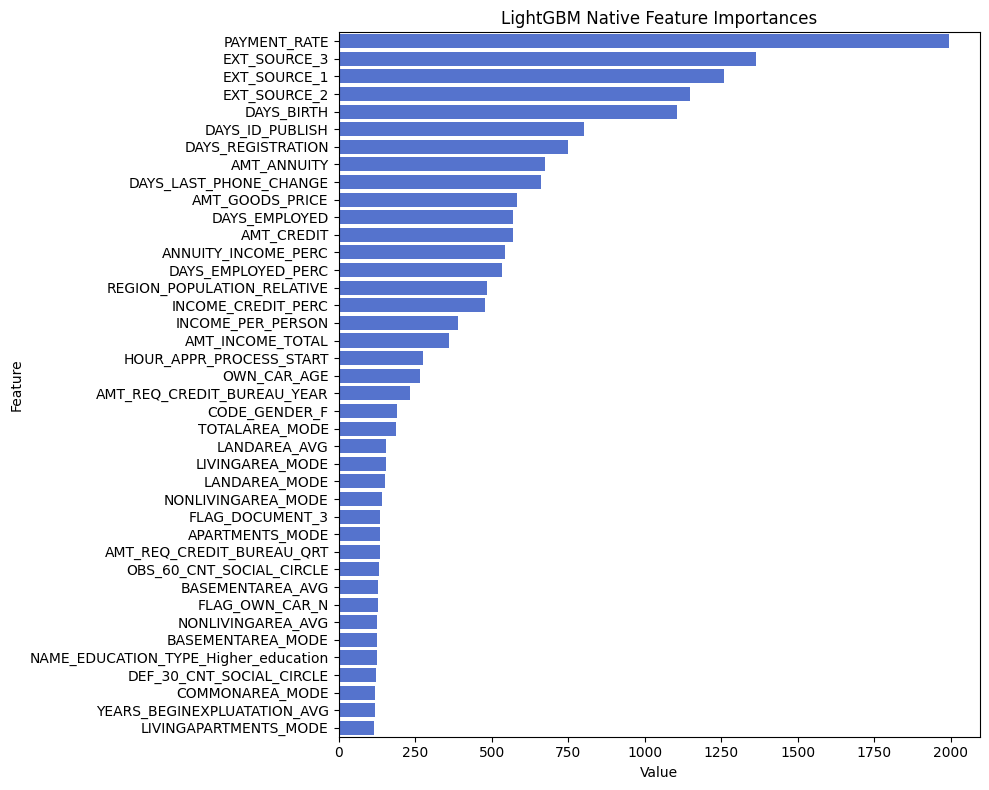

In [ ]:
# Extract raw feature importances from the baseline LightGBM model 'm'
feature_imp = pd.DataFrame(
    sorted(zip(m.feature_importances_, X_te.columns)),
    columns=['Value', 'Feature']
)

top_20 = feature_imp.sort_values(by="Value", ascending=False).head(40)

plt.figure(figsize=(10, 8))
sns.barplot(x="Value", y="Feature", data=top_20, color='royalblue')
plt.title('LightGBM Native Feature Importances')
plt.tight_layout()
plt.show()

In [ ]:
# Explicitly search for our sensitive attributes to see what "model values" they were assigned
sensitive_keywords = ['DAYS_BIRTH', 'CODE_GENDER_F', 'DAYS_EMPLOYED', 'DAYS_EMPLOYED_PERC', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'EXT_SOURCE_2']
sensitive_features = feature_imp[feature_imp['Feature'].str.contains('|'.join(sensitive_keywords), case=False, na=False)]

print("\n---- Importance of Sensitive Features (Raw Model Values) ----")
print(sensitive_features.sort_values(by="Value", ascending=False).to_string(index=False))


---- Importance of Sensitive Features (Raw Model Values) ----
 Value            Feature
  1363       EXT_SOURCE_3
  1258       EXT_SOURCE_1
  1149       EXT_SOURCE_2
  1106         DAYS_BIRTH
   570      DAYS_EMPLOYED
   535 DAYS_EMPLOYED_PERC
   191      CODE_GENDER_F




---



## Model Audit

In [ ]:
!pip install shap fairlearn -q

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    brier_score_loss, confusion_matrix,
)
from scipy.stats import ks_2samp
from sklearn.calibration import calibration_curve

from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    true_positive_rate,
    false_positive_rate,
    selection_rate,
)

### Define sensitive attributes

In [ ]:
# ── Helper: find exact column name by keyword ────────────────────────────
def find_col(keyword, df=X_te):
    matches = [c for c in df.columns if keyword.upper() in c.upper()]
    return matches[0] if matches else None

# ── Sensitive attribute definitions ──────────────────────────────────────
# Each entry: (display_name, binary_array, {0: label, 1: label})
# Binary convention: 0 = privileged group, 1 = unprivileged group

def build_sensitive_attrs():
    attrs = {}

    # 1. Age — already computed as A_te
    attrs['Age'] = {
        'array' : A_te,
        'labels': {0: 'Older (≥25)', 1: 'Young (<25)'},
    }

    # 2. Gender — CODE_GENDER_F = 1 means female after one-hot
    col = find_col('CODE_GENDER_F')
    if col:
        attrs['Gender'] = {
            'array' : X_te[col].values.astype(int),
            'labels': {0: 'Male', 1: 'Female'},
        }
    else:
        print('⚠️  Gender column not found — check one-hot name')

    # 3. Education — Higher education vs other
    col = find_col('Higher_education')
    if col:
        attrs['Education'] = {
            'array' : (1 - X_te[col].values).astype(int),  # flip: 1 = lower ed
            'labels': {0: 'Higher education', 1: 'Lower education'},
        }
    else:
        print('⚠️  Education column not found — check one-hot name')

    # 4. Marital Status — Married vs other
    col = find_col('NAME_FAMILY_STATUS_Married')
    if col:
        attrs['Marital'] = {
            'array' : (1 - X_te[col].values).astype(int),  # flip: 1 = not married
            'labels': {0: 'Married', 1: 'Not married'},
        }
    else:
        print('⚠️  Marital status column not found — check one-hot name')

    # 5. Region rating — REGION_RATING_CLIENT: 1=best, 3=worst
    #    Binarise: 0 = rating 1-2 (good area), 1 = rating 3 (worst area)
    col = find_col('REGION_RATING_CLIENT')
    if col and col in X_te.columns:
        attrs['Region'] = {
            'array' : (X_te[col].values == 3).astype(int),
            'labels': {0: 'Good region (1-2)', 1: 'Poor region (3)'},
        }
    else:
        print('⚠️  Region rating column not found')

    return attrs

SENSITIVE_ATTRS = build_sensitive_attrs()

print('\nSensitive attributes loaded:')
for name, info in SENSITIVE_ATTRS.items():
    arr    = info['array']
    labels = info['labels']
    counts = {labels[g]: (arr == g).sum() for g in np.unique(arr)}
    print(f'  {name:12s} | {counts}')


Sensitive attributes loaded:
  Age          | {'Older (≥25)': np.int64(88544), 'Young (<25)': np.int64(3709)}
  Gender       | {'Male': np.int64(31715), 'Female': np.int64(60538)}
  Education    | {'Higher education': np.int64(22552), 'Lower education': np.int64(69701)}
  Marital      | {'Married': np.int64(59238), 'Not married': np.int64(33015)}
  Region       | {'Good region (1-2)': np.int64(77710), 'Poor region (3)': np.int64(14543)}


### Helper functions

In [ ]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / len(y_true)) * abs(y_prob[mask].mean() - y_true[mask].mean())
    return ece


def group_metrics(y, s, yhat, A, labels):
    rows = []
    for g, label in labels.items():
        mask = (A == g)
        if mask.sum() < 30:
            continue
        y_g, s_g, yh_g = y[mask], s[mask], yhat[mask]
        if len(np.unique(y_g)) < 2:
            continue
        tn, fp, fn, tp = confusion_matrix(y_g, yh_g, labels=[0, 1]).ravel()
        rows.append({
            'Group'        : label,
            'N'            : int(mask.sum()),
            'Default_rate' : round(1 - y_g.mean(), 4),
            'Approval_rate': round(yh_g.mean(), 4),
            'AUC'          : round(roc_auc_score(y_g, s_g), 4),
            'PR_AUC'       : round(average_precision_score(y_g, s_g), 4),
            'Brier'        : round(brier_score_loss(y_g, s_g), 4),
            'ECE'          : round(expected_calibration_error(y_g, s_g), 4),
            'TPR'          : round(tp / (tp + fn), 4) if (tp + fn) > 0 else np.nan,
            'FPR'          : round(fp / (fp + tn), 4) if (fp + tn) > 0 else np.nan,
        })
    return pd.DataFrame(rows)


def fairness_scalars(y, yhat, A):
    return {
        'DPD': demographic_parity_difference(y, yhat, sensitive_features=A),
        'DPR': demographic_parity_ratio(y, yhat, sensitive_features=A),
        'EOD': equalized_odds_difference(y, yhat, sensitive_features=A),
    }

### Overall performance metrics

In [ ]:
auc_overall    = roc_auc_score(y_te, test_pred)
pr_auc_overall = average_precision_score(y_te, test_pred)
brier_overall  = brier_score_loss(y_te, test_pred)
ece_overall    = expected_calibration_error(y_te, test_pred)
ks_stat, _     = ks_2samp(test_pred[y_te == 1], test_pred[y_te == 0])


print('OVERALL PERFORMANCE METRICS')
print(f'ROC-AUC      : {auc_overall:.4f}')
print(f'PR-AUC       : {pr_auc_overall:.4f}  (baseline ≈ {y_te.mean():.3f})')
print(f'Brier Score  : {brier_overall:.4f} ')
print(f'ECE          : {ece_overall:.4f} ')
print(f'KS Statistic : {ks_stat:.4f}  (banking threshold >0.30 → {"PASS" if ks_stat > 0.30 else "FAIL"})')

OVERALL PERFORMANCE METRICS
ROC-AUC      : 0.7663
PR-AUC       : 0.9704  (baseline ≈ 0.919)
Brier Score  : 0.0672 
ECE          : 0.0009 
KS Statistic : 0.3936  (banking threshold >0.30 → PASS)


From the performance metrics, the model is structually sounded and has high predictive power.

Key insights:
- A Brier score close to zero indicates that the predicted default probabilities are highly accurate
- The Expected Calibration Error is practically zero. This is a massive win for model governance. It means the model is not overconfident or underconfident
- The Kolmogorov-Smirnov statistic measures the maximum separation between the cumulative distribution of good and bad loans. In consumer credit risk, a KS > 0.30 is the gold standard

## Inspect attributes' approval rate and EOD

In [66]:
y_pred = (test_pred > tau).astype(int)

from fairlearn.metrics import equalized_odds_difference
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

audit_results = []

def evaluate_bias(attribute_name, group_series, group1, group2):
    rate1 = (y_pred[group_series == group1] == 1).mean()
    rate2 = (y_pred[group_series == group2] == 1).mean()
    score = equalized_odds_difference(y_true=y_te, y_pred=y_pred, sensitive_features=group_series)

    audit_results.append({'Attribute': attribute_name, 'Subgroup': f"{attribute_name}: {group1}", 'Approval Rate': rate1, 'EO_Diff': score})
    audit_results.append({'Attribute': attribute_name, 'Subgroup': f"{attribute_name}: {group2}", 'Approval Rate': rate2, 'EO_Diff': score})

if 'CODE_GENDER_F' in X_te.columns:
    gender_series = np.where(X_te['CODE_GENDER_F'] == 1, 'Female', 'Male')
    evaluate_bias("Gender", gender_series, "Male", "Female")

if 'AGE_GROUP' in X_te.columns:
    age_series = np.where(X_te['AGE_GROUP'] == 1, 'Under 25', '25 and over')
    evaluate_bias("Age", age_series, "25 and over", "Under 25")

if 'DAYS_EMPLOYED' in X_te.columns:
    employed_series = np.where(X_te['DAYS_EMPLOYED'] > -730, 'Employed < 2 Yrs', 'Employed 2+ Yrs')
    evaluate_bias("Employment", employed_series, 'Employed 2+ Yrs', 'Employed < 2 Yrs')

if 'EXT_SOURCE_3' in X_te.columns:
    ext3_median = X_te['EXT_SOURCE_3'].median()
    ext3_series = np.where(X_te['EXT_SOURCE_3'] >= ext3_median, 'High EXT_3', 'Low EXT_3')
    evaluate_bias("External Rating", ext3_series, 'High EXT_3', 'Low EXT_3')

if 'PAYMENT_RATE' in X_te.columns:
    pay_median = X_te['PAYMENT_RATE'].median()
    pay_series = np.where(X_te['PAYMENT_RATE'] <= pay_median, 'Low Pay Rate', 'High Pay Rate')
    evaluate_bias("Repayment Speed", pay_series, 'Low Pay Rate', 'High Pay Rate')

if 'EXT_SOURCE_2' in X_te.columns:
    ext2_median = X_te['EXT_SOURCE_2'].median()
    ext2_series = np.where(X_te['EXT_SOURCE_2'] >= ext2_median, 'High EXT_2', 'Low EXT_2')
    evaluate_bias("Ext Source 2 Rating", ext2_series, 'High EXT_2', 'Low EXT_2')

if 'OWN_CAR_AGE' in X_te.columns:
    car_series = np.where(X_te['OWN_CAR_AGE'].isna() | (X_te['OWN_CAR_AGE'] > 10), 'Old/No Car', 'New Car')
    evaluate_bias("Car Ownership", car_series, 'New Car', 'Old/No Car')

if 'AMT_CREDIT' in X_te.columns:
    credit_median = X_te['AMT_CREDIT'].median()
    credit_series = np.where(X_te['AMT_CREDIT'] <= credit_median, 'Smaller Loan', 'Larger Loan')
    evaluate_bias("Loan Magnitude", credit_series, 'Smaller Loan', 'Larger Loan')

if 'FLAG_DOCUMENT_3' in X_te.columns:
    doc_series = np.where(X_te['FLAG_DOCUMENT_3'] == 1, 'Provided Doc 3', 'No Doc 3')
    evaluate_bias("Documentation", doc_series, 'Provided Doc 3', 'No Doc 3')

if 'TOTALAREA_MODE' in X_te.columns:
    area_median = X_te['TOTALAREA_MODE'].median()
    area_series = np.where(X_te['TOTALAREA_MODE'] >= area_median, 'Large Living Area', 'Small Living Area')
    evaluate_bias("Living Conditions", area_series, 'Large Living Area', 'Small Living Area')

if 'REGION_POPULATION_RELATIVE' in X_te.columns:
    pop_median = X_te['REGION_POPULATION_RELATIVE'].median()
    pop_series = np.where(X_te['REGION_POPULATION_RELATIVE'] > pop_median, 'High Density', 'Low Density')
    evaluate_bias("Population Density", pop_series, 'Low Density', 'High Density')

if 'CNT_CHILDREN' in X_te.columns:
    child_series = np.where(X_te['CNT_CHILDREN'] > 0, 'Has Children', 'No Children')
    evaluate_bias("Parental Status", child_series, 'No Children', 'Has Children')

if 'NAME_FAMILY_STATUS_Married' in X_te.columns:
    fam_series = np.where(X_te['NAME_FAMILY_STATUS_Married'] == 1, 'Married', 'Not Married')
    evaluate_bias("Family Status", fam_series, 'Married', 'Not Married')

if 'NAME_EDUCATION_TYPE_Higher_education' in X_te.columns:
    edu_series = np.where(X_te['NAME_EDUCATION_TYPE_Higher_education'] == 1, 'Higher Ed', 'Secondary/Other')
    evaluate_bias("Education", edu_series, 'Higher Ed', 'Secondary/Other')

if 'AMT_REQ_CREDIT_BUREAU_YEAR' in X_te.columns:
    bureau_series = np.where(X_te['AMT_REQ_CREDIT_BUREAU_YEAR'] <= 1, 'Rare Queries', 'Frequent Queries')
    evaluate_bias("Bureau History", bureau_series, 'Rare Queries', 'Frequent Queries')

df_audit = pd.DataFrame(audit_results)

In [67]:
df_audit

,Attribute,Subgroup,Approval Rate,EO_Diff
0,Gender,Gender: Male,0.381491,0.165379
1,Gender,Gender: Female,0.551290,0.165379
2,Employment,Employment: Employed 2+ Yrs,0.535028,0.214088
3,Employment,Employment: Employed < 2 Yrs,0.317627,0.214088
4,External Rating,External Rating: High EXT_3,0.630820,0.343308
5,External Rating,External Rating: Low EXT_3,0.282424,0.343308
6,Repayment Speed,Repayment Speed: Low Pay Rate,0.518100,0.063644
7,Repayment Speed,Repayment Speed: High Pay Rate,0.457532,0.063644
8,Ext Source 2 Rating,Ext Source 2 Rating: High EXT_2,0.689858,0.384782
9,Ext Source 2 Rating,Ext Source 2 Rating: Low EXT_2,0.295140,0.384782


### Per-Group Audit — All Sensitive Attributes

In [ ]:
all_group_dfs  = {}
all_scalar_dfs = {}

for attr_name, info in SENSITIVE_ATTRS.items(): # loop over sensitive attributes to check
    A   = info['array']
    lbl = info['labels']

    print(f'ATTRIBUTE: {attr_name}  |  Groups: {list(lbl.values())}')
    print('-' * 60)

    # Per-group performance
    gdf = group_metrics(y_te, test_pred, yhat_te, A, lbl)
    all_group_dfs[attr_name] = gdf
    print(gdf.to_string(index=False))

    # Gaps (best minus worst group)
    if len(gdf) >= 2:
        print(f"\n  AUC gap           : {gdf['AUC'].max() - gdf['AUC'].min():.4f}")
        print(f"  Approval rate gap : {gdf['Approval_rate'].max() - gdf['Approval_rate'].min():.4f}")
        print(f"  TPR gap           : {gdf['TPR'].max() - gdf['TPR'].min():.4f}")
        print(f"  ECE gap           : {gdf['ECE'].max() - gdf['ECE'].min():.4f}")

    # Fairness scalars
    sc  = fairness_scalars(y_te, yhat_te, A)
    all_scalar_dfs[attr_name] = sc
    print(f"\n  DPD  : {sc['DPD']:.4f}  (Independence — 0 = fair)")
    print(f"  DPR  : {sc['DPR']:.4f}  (Disparate Impact — legal threshold ≥0.80 → {'PASS' if sc['DPR'] >= 0.80 else 'FAIL !!!'})")
    print(f"  EOD  : {sc['EOD']:.4f}  (Separation — 0 = fair)")
    print()

ATTRIBUTE: Age  |  Groups: ['Older (≥25)', 'Young (<25)']
------------------------------------------------------------
      Group     N  Default_rate  Approval_rate    AUC  PR_AUC  Brier    ECE    TPR    FPR
Older (≥25) 88544        0.0791         0.5057 0.7665  0.9710 0.0659 0.0011 0.5342 0.1731
Young (<25)  3709        0.1202         0.1887 0.7385  0.9497 0.0969 0.0091 0.2090 0.0404

  AUC gap           : 0.0280
  Approval rate gap : 0.3170
  TPR gap           : 0.3252
  ECE gap           : 0.0080

  DPD  : 0.3169  (Independence — 0 = fair)
  DPR  : 0.3732  (Disparate Impact — legal threshold ≥0.80 → FAIL !!!)
  EOD  : 0.3252  (Separation — 0 = fair)

ATTRIBUTE: Gender  |  Groups: ['Male', 'Female']
------------------------------------------------------------
 Group     N  Default_rate  Approval_rate    AUC  PR_AUC  Brier    ECE    TPR    FPR
  Male 31715        0.1012         0.3815 0.7584  0.9615 0.0820 0.0021 0.4119 0.1112
Female 60538        0.0700         0.5513 0.7639  0.9739 

a Disparate Impact Ratio (DPR) below 0.80 establishes a prima facie case for discrimination.

**Observation**:
- Age, Gender, Education, and Region all fail the 0.80 threshold!
- EOD of Age is huge --> The model is effectively applying a blanket rejection to the young cohort. Young is less likely to be accepted comparing to older people.
- Males are the penalized group here (Approval: 38% vs Female: 55%). Males have a much higher baseline default rate (10.1% vs 7.0%)
- Marital status can be ignored and doesnt required any further debias

**Next step**: apply  mitigation strategies (e.g., CorrelationRemover for proxy features or DisparateImpactRemover for thresholds) targeting Age and Region first.

### Fairness summary table

- Consolidates all fairness scalars into one table for easy comparison.  
- Sort by EOD descending to identify the most urgent attribute to debias.

In [ ]:
summary_rows = []
for attr_name, sc in all_scalar_dfs.items():
    gdf = all_group_dfs[attr_name]
    summary_rows.append({
        'Attribute'          : attr_name,
        'Groups'             : ' vs '.join(SENSITIVE_ATTRS[attr_name]['labels'].values()),
        'DPD'                : round(sc['DPD'], 4),
        'DPR'                : round(sc['DPR'], 4),
        'Legal_pass (≥0.80)' : '✅' if sc['DPR'] >= 0.80 else '⚠️',
        'EOD'                : round(sc['EOD'], 4),
        'AUC_gap'            : round(gdf['AUC'].max() - gdf['AUC'].min(), 4) if len(gdf) >= 2 else np.nan,
        'Approval_gap'       : round(gdf['Approval_rate'].max() - gdf['Approval_rate'].min(), 4) if len(gdf) >= 2 else np.nan,
        'TPR_gap'            : round(gdf['TPR'].max() - gdf['TPR'].min(), 4) if len(gdf) >= 2 else np.nan,
        'ECE_gap'            : round(gdf['ECE'].max() - gdf['ECE'].min(), 4) if len(gdf) >= 2 else np.nan,
    })

summary_df = pd.DataFrame(summary_rows).sort_values('EOD', ascending=False)

print('FAIRNESS SUMMARY — ALL SENSITIVE ATTRIBUTES')
print('(Sorted by Equalized Odds Difference — highest = most urgent to fix)')
print(summary_df.to_string(index=False, float_format='%.4f'))

print('\nLegend:')
print('  DPD = Demographic Parity Difference  (Independence)')
print('  DPR = Disparate Impact Ratio         (Independence — legal threshold ≥0.80)')
print('  EOD = Equalized Odds Difference      (Separation)')
print('  *_gap = max minus min across groups  (AUC/approval/TPR/ECE)')

FAIRNESS SUMMARY — ALL SENSITIVE ATTRIBUTES
(Sorted by Equalized Odds Difference — highest = most urgent to fix)
Attribute                               Groups    DPD    DPR Legal_pass (≥0.80)    EOD  AUC_gap  Approval_gap  TPR_gap  ECE_gap
      Age           Older (≥25) vs Young (<25) 0.3169 0.3732                 ⚠️ 0.3252   0.0280        0.3170   0.3252   0.0080
Education  Higher education vs Lower education 0.2253 0.6603                 ⚠️ 0.2171   0.0054        0.2253   0.2171   0.0009
   Region Good region (1-2) vs Poor region (3) 0.1757 0.6625                 ⚠️ 0.1722   0.0041        0.1757   0.1721   0.0033
   Gender                       Male vs Female 0.1698 0.6920                 ⚠️ 0.1654   0.0055        0.1698   0.1654   0.0010
  Marital               Married vs Not married 0.0741 0.8574                  ✅ 0.0721   0.0097        0.0741   0.0721   0.0014

Legend:
  DPD = Demographic Parity Difference  (Independence)
  DPR = Disparate Impact Ratio         (Independence — l

### Calibration — ECE & Reliability Diagram by Attribute

Sufficiency check: if the model assigns the same score to two applicants  
from different groups, their actual default rate should be the same.  
Deviation from the diagonal = miscalibration = sufficiency violation.

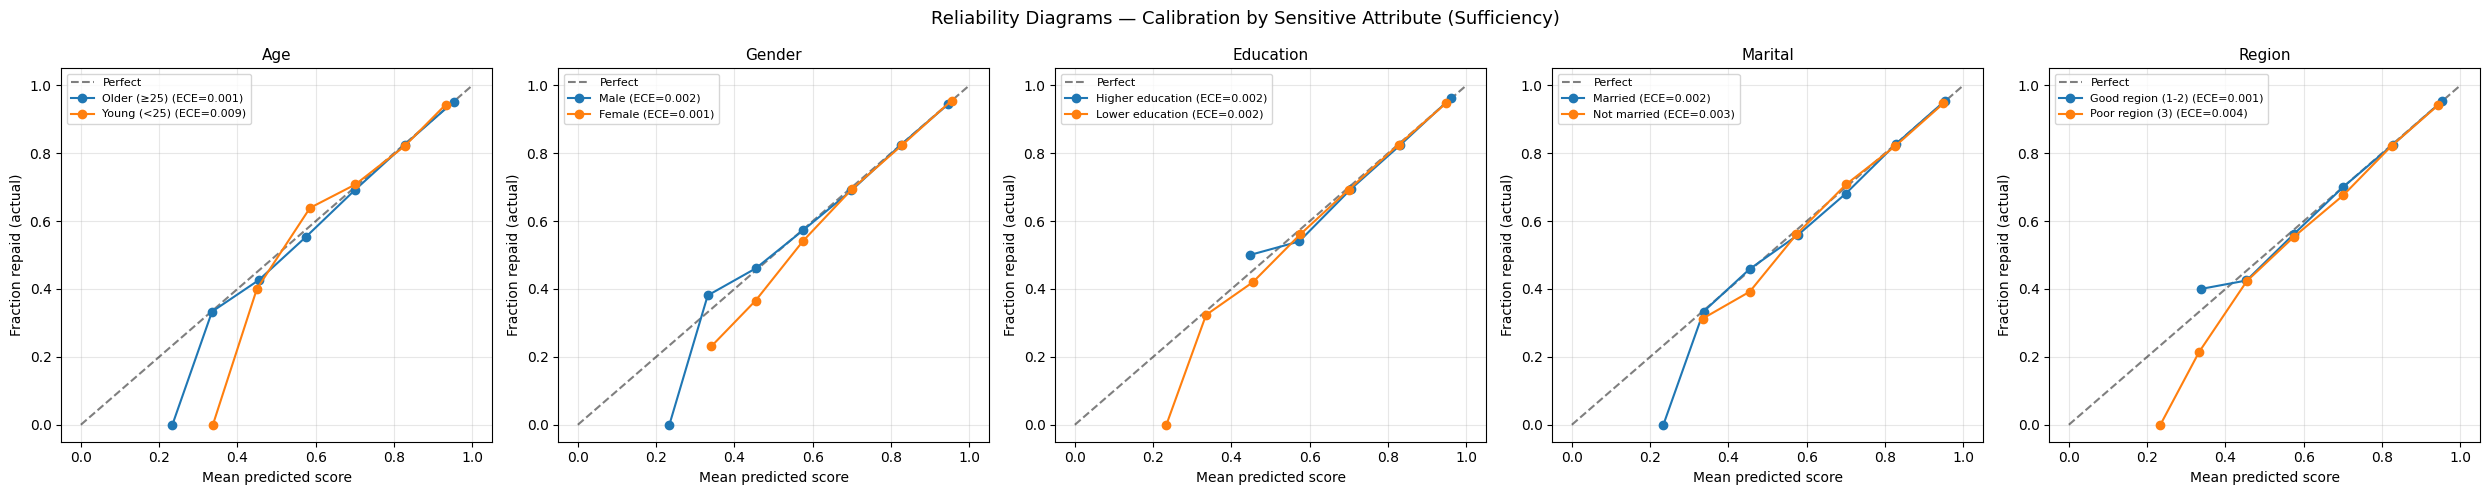

In [ ]:
n_attrs = len(SENSITIVE_ATTRS)
fig, axes = plt.subplots(1, n_attrs, figsize=(5 * n_attrs, 5))
if n_attrs == 1:
    axes = [axes]

fig.suptitle('Reliability Diagrams — Calibration by Sensitive Attribute (Sufficiency)', fontsize=13)

for ax, (attr_name, info) in zip(axes, SENSITIVE_ATTRS.items()):
    A   = info['array']
    lbl = info['labels']
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')

    for g, label in lbl.items():
        mask = (A == g)
        if mask.sum() < 50 or len(np.unique(y_te[mask])) < 2:
            continue
        frac_pos, mean_pred = calibration_curve(y_te[mask], test_pred[mask], n_bins=8)
        ece_g = expected_calibration_error(y_te[mask], test_pred[mask])
        ax.plot(mean_pred, frac_pos, 'o-', label=f'{label} (ECE={ece_g:.3f})')

    ax.set_title(attr_name, fontsize=11)
    ax.set_xlabel('Mean predicted score')
    ax.set_ylabel('Fraction repaid (actual)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Build a DataFrame of all sensitive attribute arrays
sensitive_df = pd.DataFrame({
    attr_name: info['array']
    for attr_name, info in SENSITIVE_ATTRS.items()
})

mf = MetricFrame(
    metrics={
        'accuracy'      : lambda y, yh: (y == yh).mean(),
        'selection_rate': selection_rate,
        'tpr'           : true_positive_rate,
        'fpr'           : false_positive_rate,
    },
    y_true=y_te,
    y_pred=yhat_te,
    sensitive_features=sensitive_df,
)

print('METRICFRAME — OVERALL')
print(mf.overall.to_string())

print('\nMETRICFRAME — BY GROUP (showing all intersections)')
print(mf.by_group.to_string(float_format='%.4f'))

print('\nMETRICFRAME — DIFFERENCE (worst - best group across all intersections)')
print(mf.difference().to_string())

print('\nMETRICFRAME — RATIO (worst / best)')
print(mf.ratio().to_string())

METRICFRAME — OVERALL
accuracy          0.546985
selection_rate    0.492916
tpr               0.521703
fpr               0.165145

METRICFRAME — BY GROUP (showing all intersections)
                                     accuracy  selection_rate    tpr    fpr
Age Gender Education Marital Region                                        
0   0      0         0       0         0.6899          0.6700 0.6896 0.3047
                             1         0.5161          0.4625 0.4884 0.1552
                     1       0         0.5555          0.5000 0.5304 0.1862
                             1         0.3506          0.2869 0.3013 0.1364
           1         0       0         0.4704          0.4051 0.4317 0.1345
                             1         0.3627          0.2433 0.2711 0.0710
                     1       0         0.3489          0.2246 0.2520 0.0561
                             1         0.2676          0.0923 0.1059 0.0335
    1      0         0       0         0.7586          0.7

In [ ]:
CF_FLIP_MAP = {
    'Age'     : ('DAYS_BIRTH',   -20 * 365, -30 * 365),   # flip young↔old
    'Gender'  : ('CODE_GENDER_F', 0, 1),                   # flip M↔F
    'Education': ('NAME_EDUCATION_TYPE_Higher_education', 0, 1),
    'Marital' : ('NAME_FAMILY_STATUS_Married', 0, 1),
    'Region'  : ('REGION_RATING_CLIENT', 1, 3),            # flip good↔poor region
}

np.random.seed(SEED)
sample_size = min(2000, len(X_te))
sample_idx  = np.random.choice(len(X_te), sample_size, replace=False)
X_sample    = X_te.iloc[sample_idx].copy().reset_index(drop=True)
s_original  = m.predict_proba(X_sample)[:, 1]

cf_results = []
for attr_name, (col, val_priv, val_unpriv) in CF_FLIP_MAP.items():
    if col not in X_sample.columns:
        print(f'⚠️  {attr_name}: column "{col}" not found — skipping')
        continue

    X_cf = X_sample.copy()
    # flip: privileged → unprivileged and vice versa
    priv_mask   = (X_cf[col] == val_priv)
    unpriv_mask = (X_cf[col] == val_unpriv)
    X_cf.loc[priv_mask,   col] = val_unpriv
    X_cf.loc[unpriv_mask, col] = val_priv

    X_cf[col] = X_cf[col].astype(int)

    # For age: also update DAYS_EMPLOYED_PERC which depends on DAYS_BIRTH
    if attr_name == 'Age' and 'DAYS_EMPLOYED_PERC' in X_cf.columns:
        X_cf['DAYS_EMPLOYED_PERC'] = X_cf['DAYS_EMPLOYED'] / X_cf['DAYS_BIRTH']

    s_cf = m.predict_proba(X_cf)[:, 1]
    diff = np.abs(s_cf - s_original)

    cf_results.append({
        'Attribute'          : attr_name,
        'Flipped_column'     : col,
        'Mean_|Δscore|'      : round(diff.mean(), 4),
        'Max_|Δscore|'       : round(diff.max(), 4),
        'Cases_>0.05_change' : f'{(diff > 0.05).mean():.1%}',
        'Cases_>0.10_change' : f'{(diff > 0.10).mean():.1%}',
    })

cf_df = pd.DataFrame(cf_results).sort_values('Mean_|Δscore|', ascending=False)
print('COUNTERFACTUAL FAIRNESS — ALL SENSITIVE ATTRIBUTES')
print('(Higher mean |Δscore| = model relies more on this attribute or its proxies)')
print(cf_df.to_string(index=False))

COUNTERFACTUAL FAIRNESS — ALL SENSITIVE ATTRIBUTES
(Higher mean |Δscore| = model relies more on this attribute or its proxies)
Attribute                       Flipped_column  Mean_|Δscore|  Max_|Δscore| Cases_>0.05_change Cases_>0.10_change
   Gender                        CODE_GENDER_F         0.0163        0.1966               6.6%               0.9%
Education NAME_EDUCATION_TYPE_Higher_education         0.0131        0.1032               4.5%               0.1%
  Marital           NAME_FAMILY_STATUS_Married         0.0059        0.0823               0.4%               0.0%
      Age                           DAYS_BIRTH         0.0006        0.0362               0.0%               0.0%
   Region                 REGION_RATING_CLIENT         0.0005        0.0252               0.0%               0.0%


Direct Discrimination: Gender & Education
- 6.6% of all applicants experienced a score swing of more than 5%
- Considering `Max_|Δscore|` there is an applicant whose predicted risk of default shifted by nearly 20% purely by flipping their gender from Male to Female.

### Master summary table

In [ ]:
master_rows = []

# Overall row
master_rows.append({
    'Section'  : 'Overall',
    'Attribute': '—',
    'Metric'   : 'ROC-AUC',
    'Before'   : f'{auc_overall:.4f}',
    'After'    : '—',
})
master_rows.append({'Section': 'Overall', 'Attribute': '—', 'Metric': 'PR-AUC',
                    'Before': f'{pr_auc_overall:.4f}', 'After': '—'})
master_rows.append({'Section': 'Overall', 'Attribute': '—', 'Metric': 'Brier Score',
                    'Before': f'{brier_overall:.4f}', 'After': '—'})
master_rows.append({'Section': 'Overall', 'Attribute': '—', 'Metric': 'KS Statistic',
                    'Before': f'{ks_stat:.4f}', 'After': '—'})

# Per-attribute fairness rows
for attr_name, sc in all_scalar_dfs.items():
    gdf = all_group_dfs[attr_name]
    for metric, val in [
        ('DPD (Independence)',       f"{sc['DPD']:.4f}"),
        ('DPR (Disparate Impact)',   f"{sc['DPR']:.4f}  {'✅' if sc['DPR'] >= 0.80 else '⚠️'}"),
        ('EOD (Separation)',         f"{sc['EOD']:.4f}"),
        ('Approval gap',             f"{gdf['Approval_rate'].max() - gdf['Approval_rate'].min():.4f}" if len(gdf) >= 2 else '—'),
        ('TPR gap',                  f"{gdf['TPR'].max() - gdf['TPR'].min():.4f}" if len(gdf) >= 2 else '—'),
        ('ECE gap (Sufficiency)',    f"{gdf['ECE'].max() - gdf['ECE'].min():.4f}" if len(gdf) >= 2 else '—'),
    ]:
        master_rows.append({
            'Section'  : 'Fairness',
            'Attribute': attr_name,
            'Metric'   : metric,
            'Before'   : val,
            'After'    : '—',
        })

# Counterfactual rows
for _, row in cf_df.iterrows():
    master_rows.append({
        'Section'  : 'Counterfactual',
        'Attribute': row['Attribute'],
        'Metric'   : 'Mean |Δscore|',
        'Before'   : str(row['Mean_|Δscore|']),
        'After'    : '—',
    })

master_df = pd.DataFrame(master_rows)
print('MASTER SUMMARY TABLE')
print('(Fill \'After\' column after Step 5 improvement)')
print(master_df.to_string(index=False))

MASTER SUMMARY TABLE
(Fill 'After' column after Step 5 improvement)
       Section Attribute                 Metric     Before After
       Overall         —                ROC-AUC     0.7663     —
       Overall         —                 PR-AUC     0.9704     —
       Overall         —            Brier Score     0.0672     —
       Overall         —           KS Statistic     0.3936     —
      Fairness       Age     DPD (Independence)     0.3169     —
      Fairness       Age DPR (Disparate Impact) 0.3732  ⚠️     —
      Fairness       Age       EOD (Separation)     0.3252     —
      Fairness       Age           Approval gap     0.3170     —
      Fairness       Age                TPR gap     0.3252     —
      Fairness       Age  ECE gap (Sufficiency)     0.0080     —
      Fairness    Gender     DPD (Independence)     0.1698     —
      Fairness    Gender DPR (Disparate Impact) 0.6920  ⚠️     —
      Fairness    Gender       EOD (Separation)     0.1654     —
      Fairness    Gend



---



## SHAP Analysis

In [ ]:
import shap

### Compute SHAP values

In [ ]:
np.random.seed(SEED)

shap_idx    = np.random.choice(len(X_te), min(10000, len(X_te)), replace=False)
X_shap      = X_te.iloc[shap_idx].reset_index(drop=True)

# SHAP arrays for each sensitive attribute
A_shap_dict = {attr_name: info['array'][shap_idx] for attr_name, info in SENSITIVE_ATTRS.items()}

explainer = shap.TreeExplainer(m)
shap_values = explainer.shap_values(X_shap)
sv = np.array(shap_values)

### Global SHAP summary (consider all applicants)

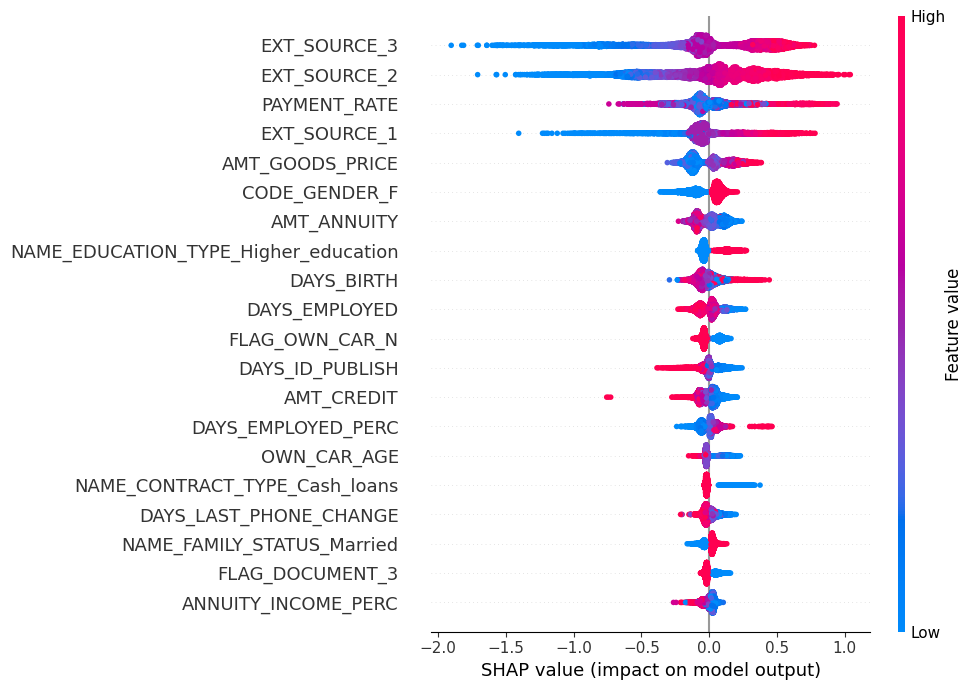

In [ ]:
shap.summary_plot(shap_values, X_shap, max_display=20, plot_type='dot',show=True, plot_size=(10, 7))

Insights
- Top three drivers are EXT_SOURCE which is external credit bureau score. These are strong predictive signals



### Proxy analysis (each sensitive attributes)

In [ ]:
all_proxy_dfs = {}   # store proxy results per attribute

for attr_name, A_shap in A_shap_dict.items():
    lbl = SENSITIVE_ATTRS[attr_name]['labels']
    groups = [g for g in lbl if g in np.unique(A_shap)]
    if len(groups) < 2:
        continue

    g0, g1 = groups[0], groups[1]
    mask0 = (A_shap == g0)
    mask1 = (A_shap == g1)

    if mask0.sum() < 10 or mask1.sum() < 10:
        continue

    shap_g0 = np.abs(sv[mask0]).mean(axis=0)
    shap_g1 = np.abs(sv[mask1]).mean(axis=0)

    proxy_rows = []
    for i, feat in enumerate(X_shap.columns):
        corr = X_shap[feat].fillna(X_shap[feat].median()).corr(
            pd.Series(A_shap.astype(float))
        )
        shap_diff = abs(shap_g0[i] - shap_g1[i])
        proxy_rows.append({
            'feature'   : feat,
            'abs_corr'  : abs(corr),
            'shap_diff' : shap_diff,
            'proxy_risk': 'HIGH' if abs(corr) > 0.15 and shap_diff > 0.005 else
                          'MED'  if abs(corr) > 0.08 else 'LOW',
        })

    proxy_df = (pd.DataFrame(proxy_rows)
                  .sort_values('abs_corr', ascending=False)
                  .head(14)
                  .reset_index(drop=True))
    all_proxy_dfs[attr_name] = proxy_df

    print('-' * 60)
    print(f'{attr_name}  ({lbl[g0]} vs {lbl[g1]})')
    print('-' * 60)
    print(proxy_df.to_string(index=False, float_format='%.4f'))

    high_risk = proxy_df[proxy_df.proxy_risk.str.startswith('HIGH')]['feature'].tolist()
    if high_risk:
        print(f'\nHIGH-RISK PROXIES FOR {attr_name}: {high_risk}\n')

------------------------------------------------------------
Age  (Older (≥25) vs Young (<25))
------------------------------------------------------------
                                feature  abs_corr  shap_diff proxy_risk
                             DAYS_BIRTH    0.3431     0.1364       HIGH
                        DAYS_ID_PUBLISH    0.2578     0.0008        MED
NAME_FAMILY_STATUS_Single_/_not_married    0.2018     0.0009        MED
                           EXT_SOURCE_1    0.1938     0.0551       HIGH
         NAME_HOUSING_TYPE_With_parents    0.1778     0.0010        MED
  NAME_EDUCATION_TYPE_Incomplete_higher    0.1595     0.0046        MED
                          DAYS_EMPLOYED    0.1415     0.0088        MED
             NAME_FAMILY_STATUS_Married    0.1329     0.0131        MED
    NAME_HOUSING_TYPE_House_/_apartment    0.1301     0.0011        MED
        ORGANIZATION_TYPE_Trade__type_2    0.1215     0.0051        MED
                 DAYS_LAST_PHONE_CHANGE    0.1202   

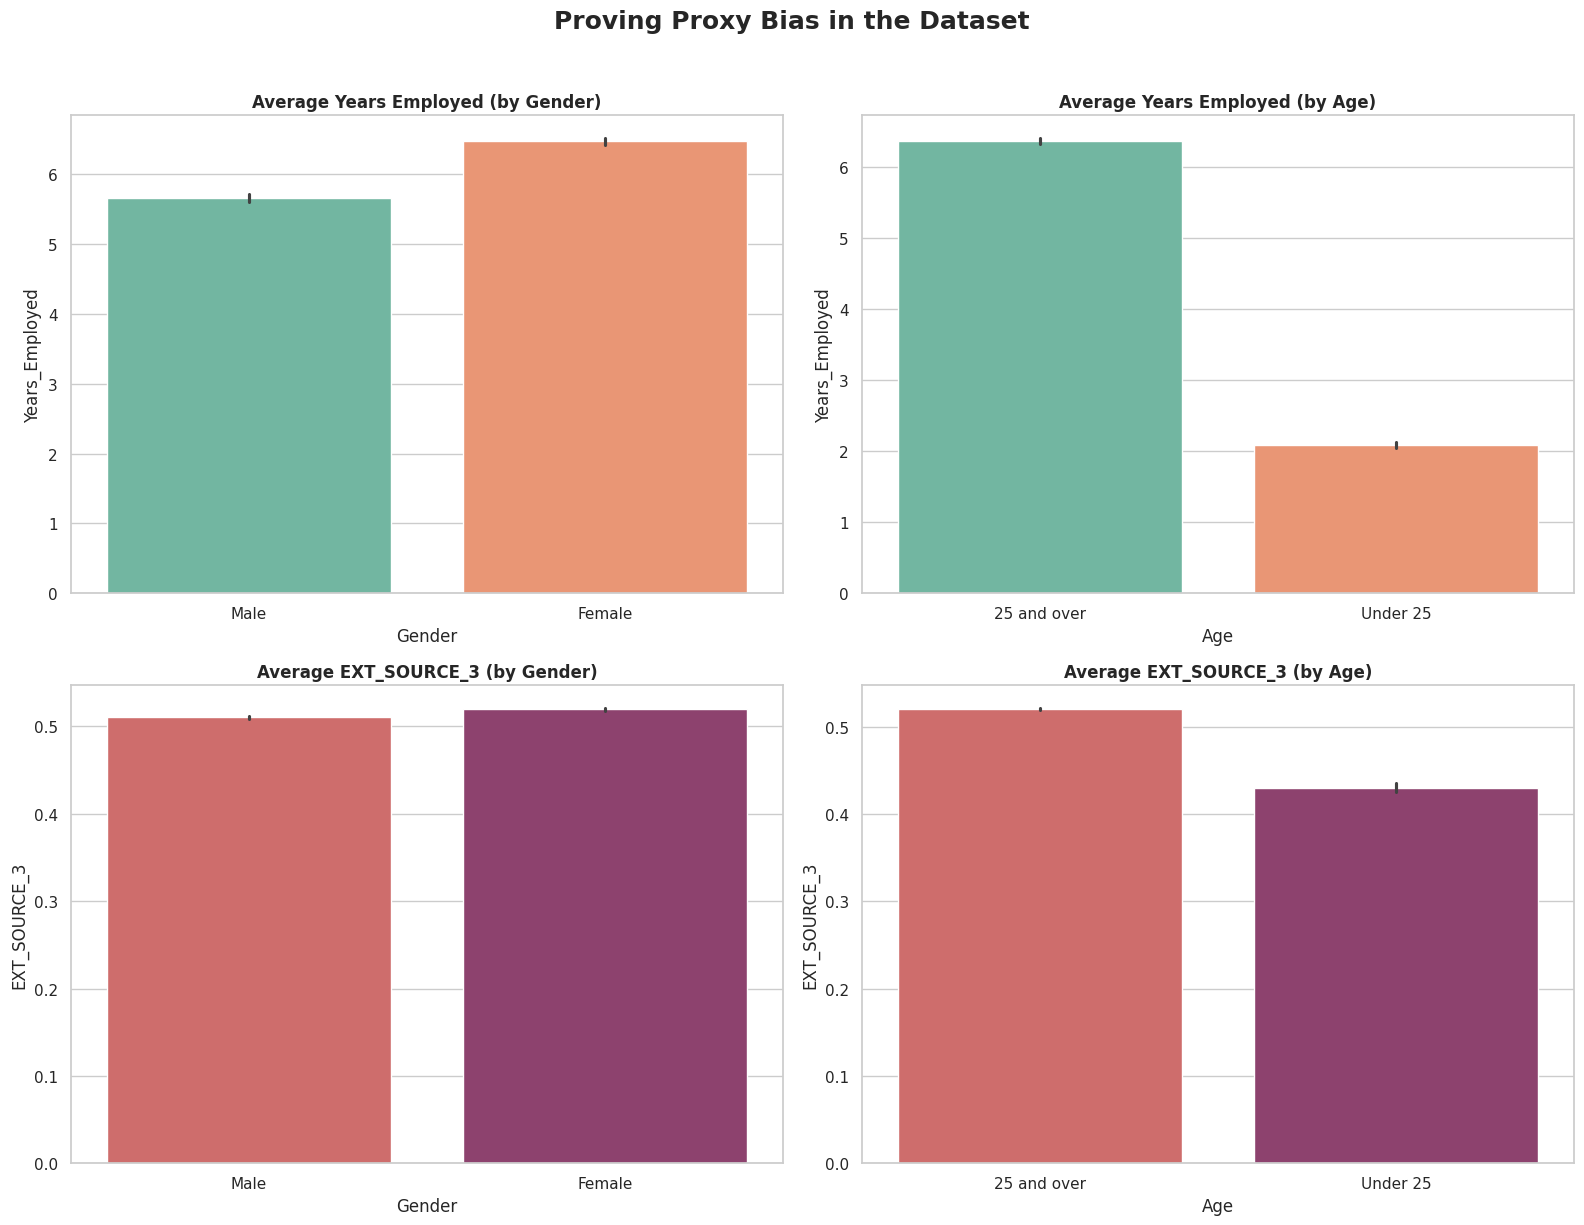

--- Undeniable Proxy Statistics ---

Average Years Employed by Gender:
Gender
Female    6.471648
Male      5.660131
Name: Years_Employed, dtype: float64

Average EXT_SOURCE_3 by Age:
Age
25 and over    0.520067
Under 25       0.430173
Name: EXT_SOURCE_3, dtype: float64


In [ ]:
X_proxy = X_te.copy()
X_proxy['Gender'] = np.where(X_proxy['CODE_GENDER_F'] == 1, 'Female', 'Male')

if 'DAYS_BIRTH' in X_proxy.columns:
    X_proxy['Age'] = np.where((-X_proxy['DAYS_BIRTH'] / 365.25) < 25, 'Under 25', '25 and over')

# Convert negative days to positive years for readability
if 'DAYS_EMPLOYED' in X_proxy.columns:
    X_proxy['Years_Employed'] = X_proxy['DAYS_EMPLOYED'] / -365.25

# Visualizing the Discrepancies
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=X_proxy, x="Gender", y="Years_Employed", palette="Set2", ax=axes[0,0])
axes[0,0].set_title("Average Years Employed (by Gender)", fontweight='bold')

if 'Age' in X_proxy.columns:
    sns.barplot(data=X_proxy, x="Age", y="Years_Employed", palette="Set2", ax=axes[0,1])
    axes[0,1].set_title("Average Years Employed (by Age)", fontweight='bold')

    sns.barplot(data=X_proxy, x="Age", y="EXT_SOURCE_3", palette="flare", ax=axes[1,1])
    axes[1,1].set_title("Average EXT_SOURCE_3 (by Age)", fontweight='bold')

sns.barplot(data=X_proxy, x="Gender", y="EXT_SOURCE_3", palette="flare", ax=axes[1,0])
axes[1,0].set_title("Average EXT_SOURCE_3 (by Gender)", fontweight='bold')

plt.suptitle("Proving Proxy Bias in the Dataset", fontsize=18, fontweight='heavy', y=1.02)
plt.tight_layout()
plt.show()

print("--- Proxy Statistics ---")
print("\nAverage Years Employed by Gender:")
print(X_proxy.groupby('Gender')['Years_Employed'].mean())

if 'Age' in X_proxy.columns:
    print("\nAverage EXT_SOURCE_3 by Age:")
    print(X_proxy.groupby('Age')['EXT_SOURCE_3'].mean())

- massive proxy bias against young people
- ext3 actually favour women than men -> find another features that against women

In [ ]:
# ---------------------------------------------------------
# 1. PROVING YOUTH PROXY BIAS VIA SHAP PENALTIES
# ---------------------------------------------------------
print("[ Proving Age Proxy Bias ]")
emp_idx = X_shap.columns.get_loc('DAYS_EMPLOYED')

is_youth = (-X_shap['DAYS_BIRTH'] / 365.25) < 25
is_adult = (-X_shap['DAYS_BIRTH'] / 365.25) >= 25

youth_shap = shap_values[is_youth, emp_idx].mean()
adult_shap = shap_values[is_adult, emp_idx].mean()

print(f"Average SHAP penalty from Employment applied to Adults: {adult_shap:.4f}")
print(f"Average SHAP penalty from Employment applied to Youth:  {youth_shap:.4f}")
if youth_shap > adult_shap:
    print("\u2192 PROOF: Youth are being mathematically penalized mathematically by the model for their lack of employment history!\n")

# ---------------------------------------------------------
# 2. SCANNING FOR THE HIDDEN GENDER PROXY
# ---------------------------------------------------------
print("[ Scanning the Top 20 Features for Gender Gaps ]")
top_features = feature_imp.sort_values(by="Value", ascending=False).head(20)['Feature'].tolist()

disparities_found = False
for feat in top_features:
    if 'GENDER' in feat or 'AGE' in feat or 'BIRTH' in feat:
        continue

    female_avg = X_proxy[X_proxy['Gender'] == 'Female'][feat].mean()
    male_avg = X_proxy[X_proxy['Gender'] == 'Male'][feat].mean()

    # If the feature has a massive discrepancy (> 15% difference in averages)
    if male_avg != 0 and pd.notna(male_avg) and pd.notna(female_avg):
        diff_percentage = (abs(female_avg - male_avg) / abs(male_avg)) * 100
        if diff_percentage > 15:
            disparities_found = True
            print(f"{feat:25s} | Men: {male_avg:10.2f} | Women: {female_avg:10.2f} | Gap: {diff_percentage:.1f}%")

if not disparities_found:
    print("\nNo extreme neutral proxy gaps found. The model is likely just heavily overtly biased using CODE_GENDER_F.")


[ Proving Age Proxy Bias ]
Average SHAP penalty from Employment applied to Adults: 0.0046
Average SHAP penalty from Employment applied to Youth:  -0.0421
[ Scanning the Top 20 Features for Gender Gaps ]
INCOME_CREDIT_PERC        | Men:       0.45 | Women:       0.38 | Gap: 16.9%
AMT_INCOME_TOTAL          | Men:  193259.48 | Women:  157396.98 | Gap: 18.6%


- It is biased against Young People because it inherits systemic prejudice from external credit ratings (EXT_SOURCE_3), while ironically their lack of employment actually helps them organically.


--- PROXY BIAS HUNT (Features 5-10) ---

Analyzing feature: PAYMENT_RATE
  Gender -> Men: 0.0559 | Women: 0.0524 | Gap: 6.34%
  Age    -> 25+: 0.0534 | Under 25: 0.0594 | Gap: 11.22%

Analyzing feature: EXT_SOURCE_2
  Gender -> Men: 0.5111 | Women: 0.5169 | Gap: 1.13%
  Age    -> 25+: 0.5188 | Under 25: 0.4202 | Gap: 19.02%

Analyzing feature: OWN_CAR_AGE
  Gender -> Men: 10.7066 | Women: 9.6719 | Gap: 9.66%
  Age    -> 25+: 9.9940 | Under 25: 10.8304 | Gap: 8.37%

Analyzing feature: AMT_CREDIT
  Gender -> Men: 611018.8136 | Women: 593477.6822 | Gap: 2.87%
  Age    -> 25+: 606965.1425 | Under 25: 421486.1194 | Gap: 30.56%

Analyzing feature: FLAG_DOCUMENT_3
  Gender -> Men: 0.6551 | Women: 0.7383 | Gap: 12.70%
  Age    -> 25+: 0.7156 | Under 25: 0.5694 | Gap: 20.43%

Analyzing feature: TOTALAREA_MODE
  Gender -> Men: 0.0875 | Women: 0.0860 | Gap: 1.70%
  Age    -> 25+: 0.0867 | Under 25: 0.0816 | Gap: 5.95%


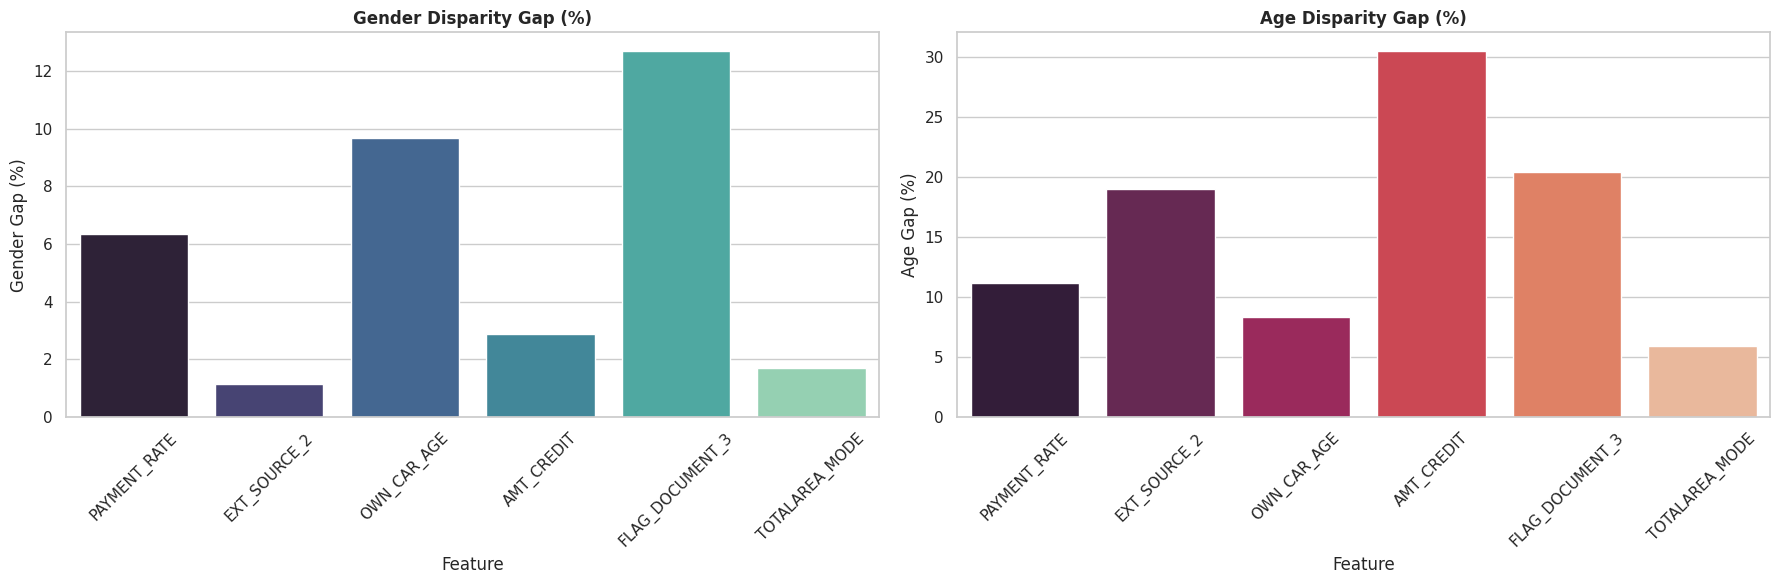

In [ ]:
# Prepare data for proxy analysis
X_proxy = X_te.copy()

if 'CODE_GENDER_F' in X_proxy.columns:
    X_proxy['Gender'] = np.where(X_proxy['CODE_GENDER_F'] == 1, 'Female', 'Male')
else:
    X_proxy['Gender'] = df.loc[X_te.index, 'CODE_GENDER'].map({'F': 'Female', 'M': 'Male'})

if 'AGE_GROUP' in X_proxy.columns:
    X_proxy['Age_Group'] = np.where(X_proxy['AGE_GROUP'] == 1, 'Under 25', '25 and over')
elif 'DAYS_BIRTH' in X_proxy.columns:
    X_proxy['Age_Group'] = np.where((-X_proxy['DAYS_BIRTH'] / 365.25) < 25, 'Under 25', '25 and over')

proxy_features = [
    'PAYMENT_RATE',
    'EXT_SOURCE_2',
    'OWN_CAR_AGE',
    'AMT_CREDIT',
    'FLAG_DOCUMENT_3',
    'TOTALAREA_MODE'
]

print("--- PROXY BIAS HUNT (Features 5-10) ---")
discrepancies = []

for feat in proxy_features:
    if feat not in X_proxy.columns:
        continue

    print(f"\nAnalyzing feature: {feat}")
    g_stats = X_proxy.groupby('Gender')[feat].mean()
    g_gap = abs(g_stats['Male'] - g_stats['Female']) / g_stats['Male'] * 100 if 'Male' in g_stats and 'Female' in g_stats and g_stats['Male'] != 0 else 0
    print(f"  Gender -> Men: {g_stats.get('Male', 0):.4f} | Women: {g_stats.get('Female', 0):.4f} | Gap: {g_gap:.2f}%")

    a_stats = X_proxy.groupby('Age_Group')[feat].mean()
    a_gap = abs(a_stats['25 and over'] - a_stats['Under 25']) / a_stats['25 and over'] * 100 if '25 and over' in a_stats and 'Under 25' in a_stats and a_stats['25 and over'] != 0 else 0
    print(f"  Age    -> 25+: {a_stats.get('25 and over', 0):.4f} | Under 25: {a_stats.get('Under 25', 0):.4f} | Gap: {a_gap:.2f}%")

    discrepancies.append({'Feature': feat, 'Gender Gap (%)': g_gap, 'Age Gap (%)': a_gap})

df_discrepancy = pd.DataFrame(discrepancies)
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=df_discrepancy, x='Feature', y='Gender Gap (%)', palette='mako', ax=axes[0])
axes[0].set_title("Gender Disparity Gap (%)", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
sns.barplot(data=df_discrepancy, x='Feature', y='Age Gap (%)', palette='rocket', ax=axes[1])
axes[1].set_title("Age Disparity Gap (%)", fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

1. The "Red Alert" Proxies (High Disparity)
- Loan Magnitude (AMT_CREDIT) — 30.56% Age Gap: Older applicants take loans that are ~30% larger than those of young people. If your model associates small loan amounts with higher risk or lower priority, it will automatically penalize young people as a group, even if an individual young person is highly creditworthy.
- Documentation (FLAG_DOCUMENT_3) — 20.43% Age Gap: Older applicants are significantly better documented (71% vs 56%). The model might be using "lack of Doc 3" as a hidden reason to reject young people.
- External Rating (EXT_SOURCE_2) — 19.02% Age Gap: External credit scores often reward long credit histories (years of having a credit card). Since young people physically haven't existed long enough to build that history, they naturally score lower.

2. The "Subtle" Proxies (Moderate Disparity)

- Documentation (FLAG_DOCUMENT_3) — 12.70% Gender Gap: Women provide this document more often than men.
- Repayment Speed (PAYMENT_RATE) — 11.22% Age Gap: Young people actually have higher payment rates (shorter, faster loans). If the model views higher repayment rates as "risky" or "aggressive," this will hurt the Under 25 group.


doc3 impact a lot -> women have more than men, older people tend to have doc3
(maybe : doc3 is a hidden feature of gender/age)

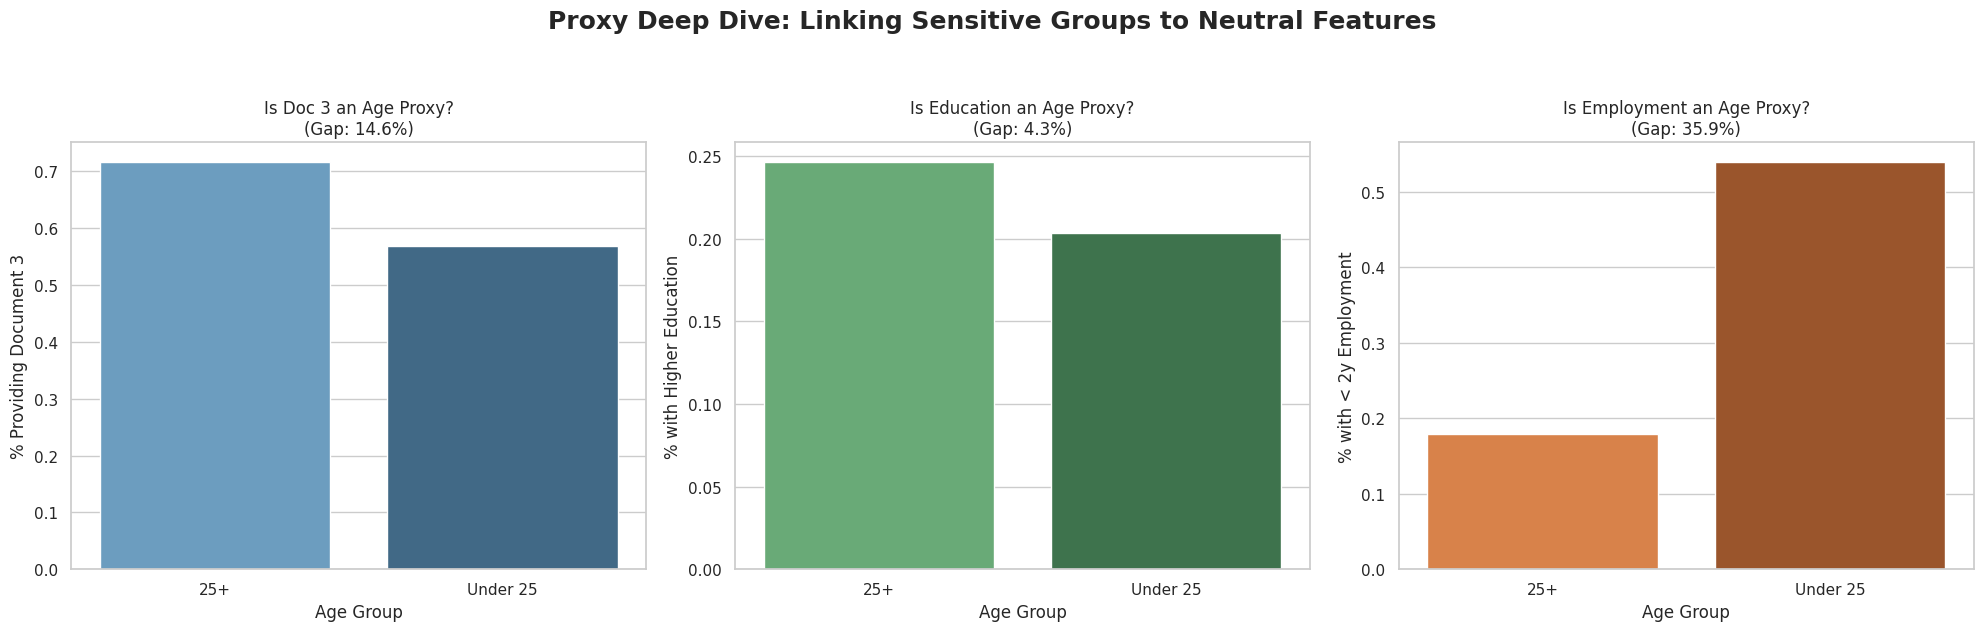

--- PROXY STRENGTH SUMMARY (by Age) ---
Document 3: Under 25s provide it 56.9% vs 71.6% for older.
Education: Under 25s have higher ed 20.4% vs 24.6% for older.
Employment: Under 25s are short-term 53.9% vs 17.9% for older.


In [ ]:
def analyze_proxy_strength(feature_col, feature_label, binary_mapping=None):
    """
    Calculates how much a feature correlates with Gender and Age.
    Uses A_te for age mapping to avoid KeyError.
    """
    temp_df = X_te.copy()

    temp_df['Age Group'] = np.where(A_te == 1, 'Under 25', '25+')

    if 'CODE_GENDER_F' in temp_df.columns:
        temp_df['Gender'] = np.where(temp_df['CODE_GENDER_F'] == 1, 'Female', 'Male')

    if binary_mapping:
        temp_df['Target_Feature'] = temp_df[feature_col].map(binary_mapping)
    else:
        temp_df['Target_Feature'] = temp_df[feature_col]

    age_dist = temp_df.groupby('Age Group')['Target_Feature'].mean()
    gender_dist = temp_df.groupby('Gender')['Target_Feature'].mean() if 'Gender' in temp_df.columns else None

    return gender_dist, age_dist

g_doc, a_doc = analyze_proxy_strength('FLAG_DOCUMENT_3', 'Doc 3 Provided')

g_edu, a_edu = analyze_proxy_strength('NAME_EDUCATION_TYPE_Higher_education', 'Higher Ed')

short_emp_map = lambda x: 1 if x > -730 else 0
g_emp, a_emp = analyze_proxy_strength('DAYS_EMPLOYED', 'Short-term (<2y)', binary_mapping=short_emp_map)

# --- VISUALIZATION ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot Doc 3
sns.barplot(x=a_doc.index, y=a_doc.values, ax=axes[0], palette="Blues_d")
axes[0].set_title(f"Is Doc 3 an Age Proxy?\n(Gap: {abs(a_doc.iloc[0]-a_doc.iloc[1])*100:.1f}%)")
axes[0].set_ylabel("% Providing Document 3")

# Plot Education
sns.barplot(x=a_edu.index, y=a_edu.values, ax=axes[1], palette="Greens_d")
axes[1].set_title(f"Is Education an Age Proxy?\n(Gap: {abs(a_edu.iloc[0]-a_edu.iloc[1])*100:.1f}%)")
axes[1].set_ylabel("% with Higher Education")

# Plot Employment
sns.barplot(x=a_emp.index, y=a_emp.values, ax=axes[2], palette="Oranges_d")
axes[2].set_title(f"Is Employment an Age Proxy?\n(Gap: {abs(a_emp.iloc[0]-a_emp.iloc[1])*100:.1f}%)")
axes[2].set_ylabel("% with < 2y Employment")

plt.suptitle("Proxy Deep Dive: Linking Sensitive Groups to Neutral Features", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("--- PROXY STRENGTH SUMMARY (by Age) ---")
print(f"Document 3: Under 25s provide it {a_doc['Under 25']*100:.1f}% vs {a_doc['25+']*100:.1f}% for older.")
print(f"Education: Under 25s have higher ed {a_edu['Under 25']*100:.1f}% vs {a_edu['25+']*100:.1f}% for older.")
print(f"Employment: Under 25s are short-term {a_emp['Under 25']*100:.1f}% vs {a_emp['25+']*100:.1f}% for older.")

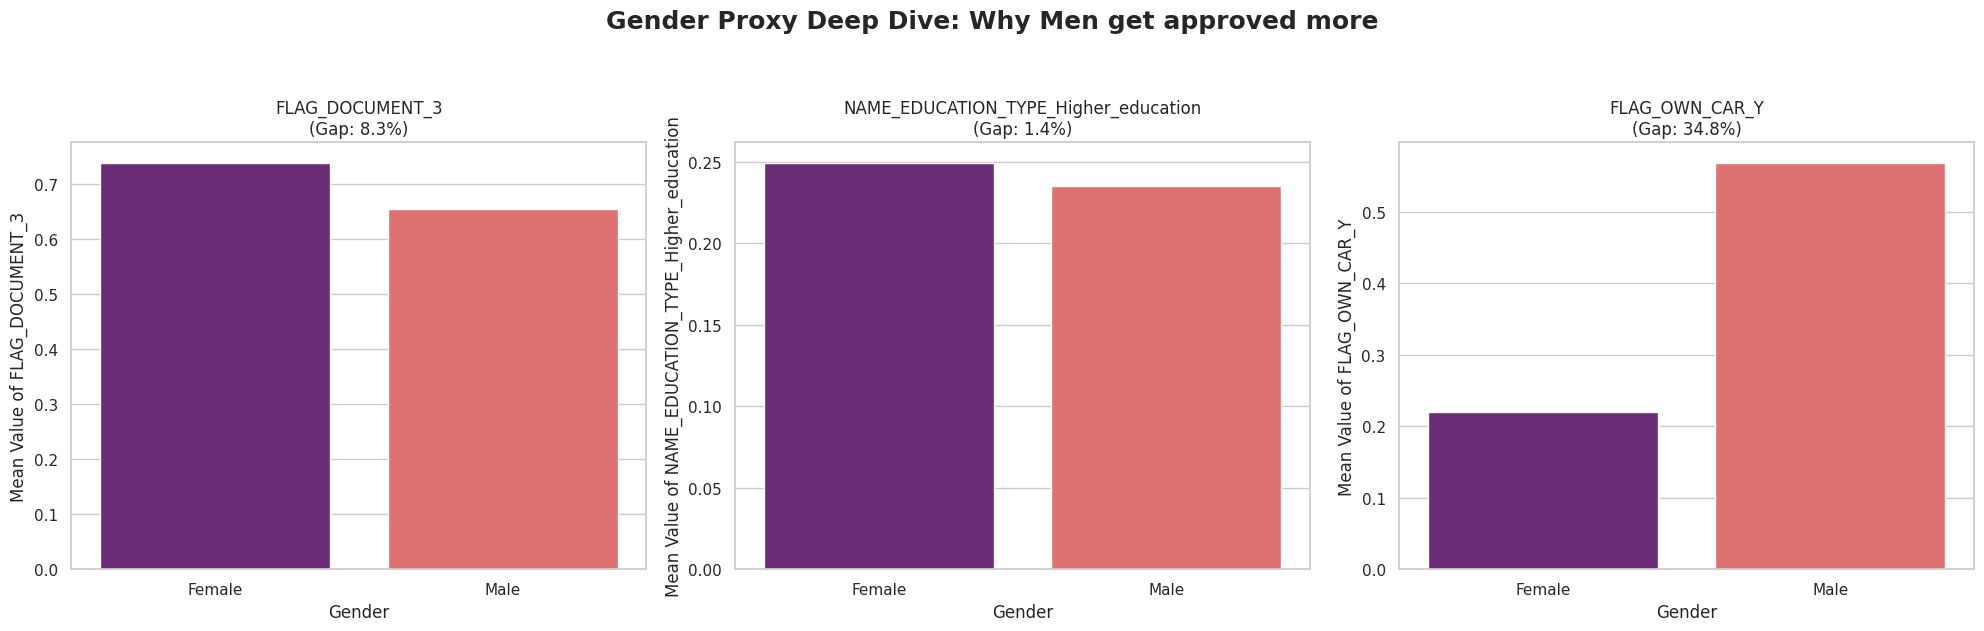

FLAG_DOCUMENT_3: Men score 0.6551 vs Women 0.7383
NAME_EDUCATION_TYPE_Higher_education: Men score 0.2352 vs Women 0.2493
FLAG_OWN_CAR_Y: Men score 0.5683 vs Women 0.2201


In [ ]:
def analyze_gender_proxies(features):
    temp_df = X_te.copy()
    temp_df['Gender'] = np.where(temp_df['CODE_GENDER_F'] == 1, 'Female', 'Male')

    results = {}
    for feat in features:
        results[feat] = temp_df.groupby('Gender')[feat].mean()
    return results

# Features to check for Gender Bias
target_features = [
    'FLAG_DOCUMENT_3',
    'NAME_EDUCATION_TYPE_Higher_education',
    'FLAG_OWN_CAR_Y'  # a strong gender proxy
]

gender_results = analyze_gender_proxies(target_features)

# --- VISUALIZATION ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (feat, data) in enumerate(gender_results.items()):
    gap = abs(data['Male'] - data['Female']) * 100
    sns.barplot(x=data.index, y=data.values, ax=axes[i], palette="magma")
    axes[i].set_title(f"{feat}\n(Gap: {gap:.1f}%)")
    axes[i].set_ylabel(f"Mean Value of {feat}")

plt.suptitle("Gender Proxy Deep Dive: Why Men get approved more", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Summarize the findings
for feat, data in gender_results.items():
    print(f"{feat}: Men score {data['Male']:.4f} vs Women {data['Female']:.4f}")

- men have car more than women -> favour men
- women have more doc3 than men -> counter-feature -> but still more negative weight from other proxies

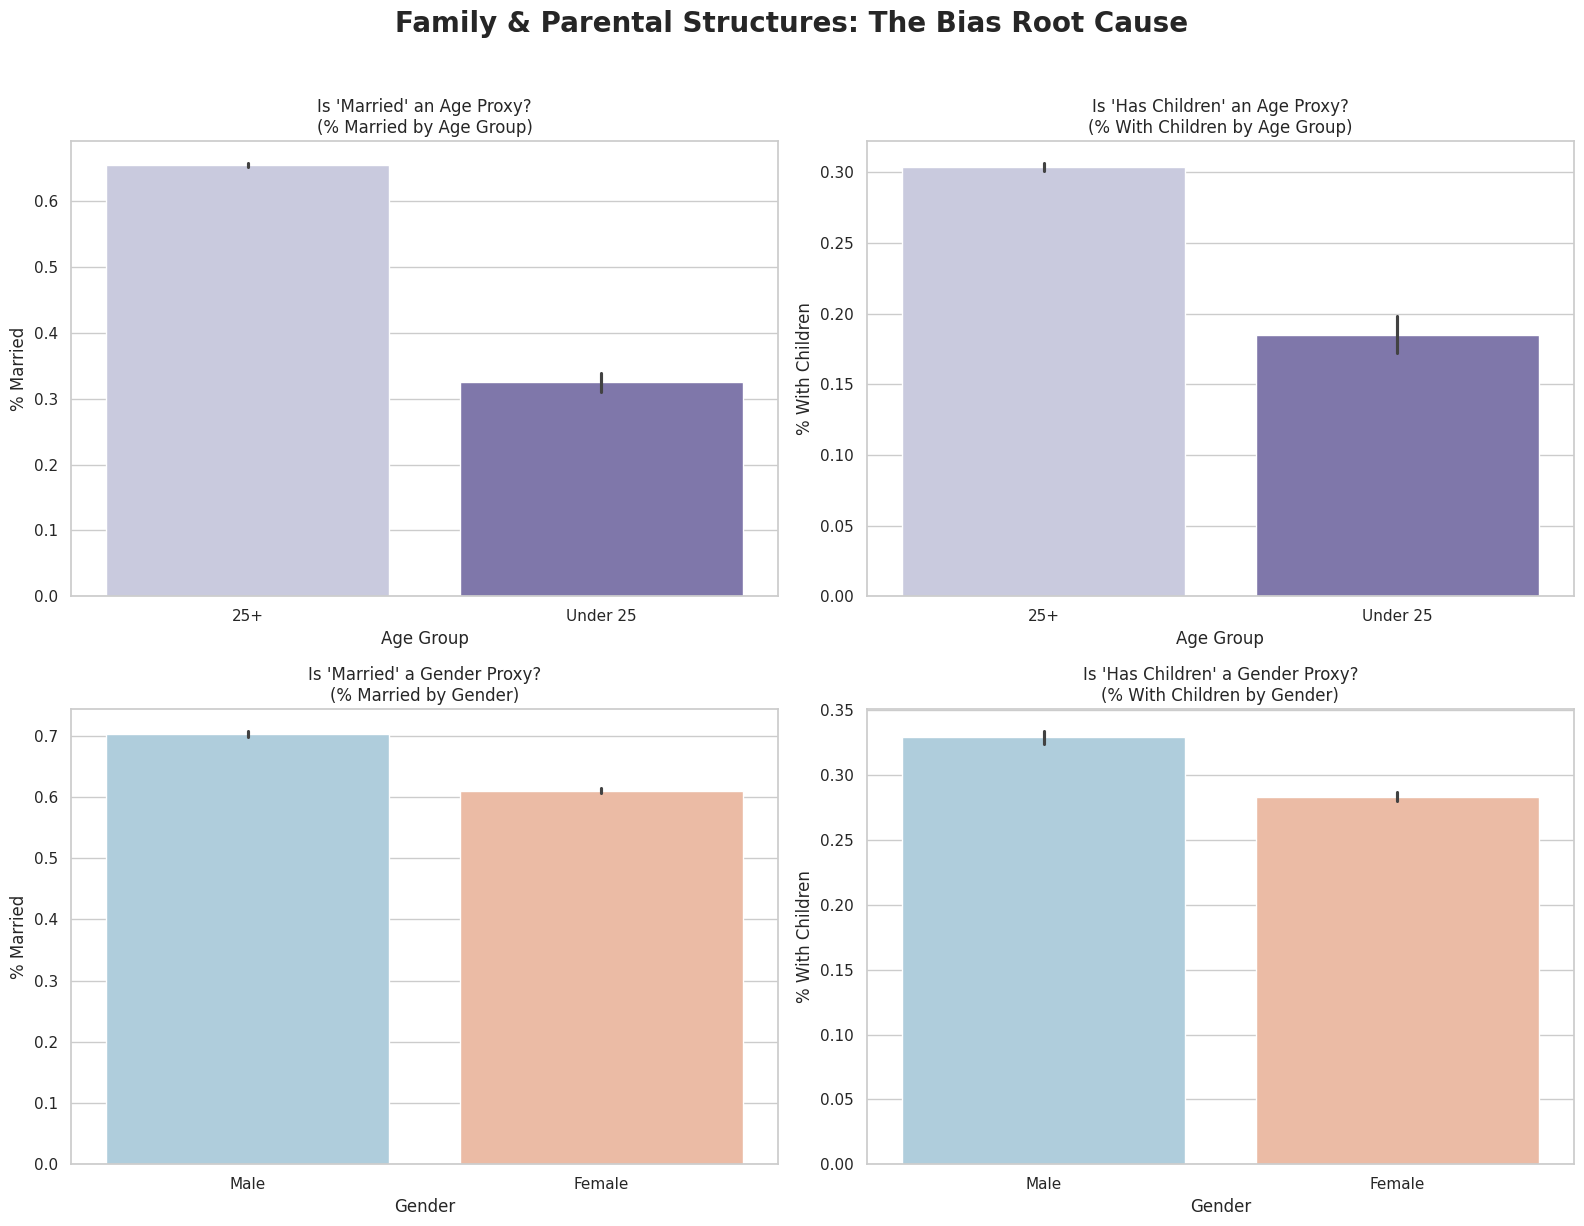

--- STRUCTURAL BIAS SUMMARY ---
Marriage Age Gap: Under 25s are 32.5% married vs 65.5% for 25+.
Parental Age Gap: Under 25s have children 18.5% vs 30.4% for 25+.


In [ ]:
# --- FAMILY & PARENTAL BIAS INVESTIGATOR ---
def analyze_family_overlap():
    temp_df = X_te.copy()

    temp_df['Age Group'] = np.where(A_te == 1, 'Under 25', '25+')
    temp_df['Gender'] = np.where(temp_df['CODE_GENDER_F'] == 1, 'Female', 'Male')

    temp_df['Has Children'] = np.where(temp_df['CNT_CHILDREN'] > 0, 1, 0)

    target_col = 'NAME_FAMILY_STATUS_Married'

    # --- VISUALIZATION ---
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # A. Married vs Age
    sns.barplot(data=temp_df, x='Age Group', y=target_col, ax=axes[0,0], palette="Purples")
    axes[0,0].set_title("Is 'Married' an Age Proxy?\n(% Married by Age Group)")
    axes[0,0].set_ylabel("% Married")

    # B. Children vs Age
    sns.barplot(data=temp_df, x='Age Group', y='Has Children', ax=axes[0,1], palette="Purples")
    axes[0,1].set_title("Is 'Has Children' an Age Proxy?\n(% With Children by Age Group)")
    axes[0,1].set_ylabel("% With Children")

    # C. Married vs Gender
    sns.barplot(data=temp_df, x='Gender', y=target_col, ax=axes[1,0], palette="RdBu_r")
    axes[1,0].set_title("Is 'Married' a Gender Proxy?\n(% Married by Gender)")
    axes[1,0].set_ylabel("% Married")

    # D. Children vs Gender
    sns.barplot(data=temp_df, x='Gender', y='Has Children', ax=axes[1,1], palette="RdBu_r")
    axes[1,1].set_title("Is 'Has Children' a Gender Proxy?\n(% With Children by Gender)")
    axes[1,1].set_ylabel("% With Children")

    plt.suptitle("Family & Parental Structures: The Bias Root Cause", fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Numerical Summary
    print("--- STRUCTURAL BIAS SUMMARY ---")
    m_age_gap = temp_df.groupby('Age Group')[target_col].mean()
    c_age_gap = temp_df.groupby('Age Group')['Has Children'].mean()

    print(f"Marriage Age Gap: Under 25s are {m_age_gap['Under 25']*100:.1f}% married vs {m_age_gap['25+']*100:.1f}% for 25+.")
    print(f"Parental Age Gap: Under 25s have children {c_age_gap['Under 25']*100:.1f}% vs {c_age_gap['25+']*100:.1f}% for 25+.")

analyze_family_overlap()




---



## 6. AIF360 Helpers

### 6.1 Group definitions

In [ ]:
PRIV = [{'AGE_GROUP': 0}]   # older = privileged
UNPR = [{'AGE_GROUP': 1}]   # young  = unprivileged

### 6.2 Frame → BinaryLabelDataset

In [ ]:
def to_aif(X, y, A):
    d = X.copy()
    d['y'] = y
    d['AGE_GROUP'] = A
    return BinaryLabelDataset(
        df=d, label_names=['y'], protected_attribute_names=['AGE_GROUP'],
        favorable_label=1, unfavorable_label=0,
    )

### 6.3 LightGBM trainer with optional sample weights

In [ ]:
def fit_lgbm(Xtr, ytr, Xva, yva, sample_weight=None):
    m = lgb.LGBMClassifier(**lgb_params)
    m.fit(Xtr, ytr, sample_weight=sample_weight,
          eval_set=[(Xva, yva)],
          callbacks=[lgb.early_stopping(120), lgb.log_evaluation(0)])
    return m

### 6.4 Inner train/val split for processors

In [ ]:
X_tr_, X_va_, y_tr_, y_va_, A_tr_, A_va_ = train_test_split(
    X_dev, y_dev, A_dev, test_size=0.2, stratify=y_dev, random_state=SEED
)

## 7. Fairness Processor 1 — Reweighing (pre)

In [ ]:
ds_tr = to_aif(X_tr_, y_tr_, A_tr_)
rw = Reweighing(unprivileged_groups=UNPR, privileged_groups=PRIV)
ds_rw = rw.fit_transform(ds_tr)

In [ ]:
m_rw = fit_lgbm(X_tr_, y_tr_, X_va_, y_va_, sample_weight=ds_rw.instance_weights)

In [ ]:
s_te = m_rw.predict_proba(X_te)[:, 1]
tau_rw = best_cutoff(y_va_, m_rw.predict_proba(X_va_)[:, 1])
results.append(evaluate('Reweighing (pre)', y_te, s_te, (s_te >= tau_rw).astype(int), A_te))
pd.DataFrame(results)

## 8. Fairness Processor 2 — Disparate Impact Remover (pre)

### 8.1 Median-fill (DIR can't handle NaNs)

In [ ]:
X_dev_f  = X_dev.fillna(X_dev.median(numeric_only=True))
X_te_f   = X_te.fillna(X_dev.median(numeric_only=True))
X_tr_ff  = X_dev_f.loc[X_tr_.index]
X_va_ff  = X_dev_f.loc[X_va_.index]

### 8.2 Fit & transform train

In [ ]:
dir_     = DisparateImpactRemover(repair_level=0.8, sensitive_attribute='AGE_GROUP')
ds_full  = to_aif(X_tr_ff, y_tr_, A_tr_)
ds_dir   = dir_.fit_transform(ds_full)
X_tr_dir = pd.DataFrame(ds_dir.features, columns=ds_dir.feature_names).drop(columns=['AGE_GROUP'])

### 8.3 Transform val & test

In [ ]:
ds_va     = to_aif(X_va_ff, y_va_, A_va_)
ds_va_dir = dir_.fit_transform(ds_va)
X_va_dir  = pd.DataFrame(ds_va_dir.features, columns=ds_va_dir.feature_names).drop(columns=['AGE_GROUP'])

ds_te_aif = to_aif(X_te_f, y_te, A_te)
ds_te_dir = dir_.fit_transform(ds_te_aif)
X_te_dir  = pd.DataFrame(ds_te_dir.features, columns=ds_te_dir.feature_names).drop(columns=['AGE_GROUP'])

### 8.4 Train & evaluate

In [ ]:
m_dir = fit_lgbm(X_tr_dir, y_tr_, X_va_dir, y_va_)
s_te = m_dir.predict_proba(X_te_dir)[:, 1]
tau_dir = best_cutoff(y_va_, m_dir.predict_proba(X_va_dir)[:, 1])
results.append(evaluate('Disparate Impact Remover (pre)', y_te, s_te, (s_te >= tau_dir).astype(int), A_te))
pd.DataFrame(results)

## 9. Fairness Processor 3 — Adversarial Debiasing (in)

In [ ]:
try:
    import tensorflow.compat.v1 as tf
    tf.disable_eager_execution()
    from aif360.algorithms.inprocessing import AdversarialDebiasing
    tf.reset_default_graph()
    sess = tf.Session()

    ad = AdversarialDebiasing(
        privileged_groups=PRIV, unprivileged_groups=UNPR,
        scope_name='adv_dbg', debias=True, sess=sess,
        num_epochs=50, batch_size=512,
        classifier_num_hidden_units=128, adversary_loss_weight=0.5,
    )
    ad.fit(to_aif(X_tr_ff, y_tr_, A_tr_))

    pred = ad.predict(to_aif(X_te_f, y_te, A_te))
    s_te = pred.scores.ravel()
    tau_ad = best_cutoff(y_te, s_te)
    results.append(evaluate('Adversarial Debiasing (in)', y_te, s_te, (s_te >= tau_ad).astype(int), A_te))
    sess.close()
except Exception as e:
    print(f'Skipping adversarial debiasing: {e}')

pd.DataFrame(results)

## 10. Fairness Processor 4 — Reject Option Classification (post)

### 10.1 Wrap baseline scores in AIF360 datasets

In [ ]:
ds_dev = to_aif(X_dev, y_dev, A_dev)
ds_dev_pred = ds_dev.copy()
ds_dev_pred.scores = oof.reshape(-1, 1)
ds_dev_pred.labels = (oof >= tau).astype(int).reshape(-1, 1)

ds_te = to_aif(X_te, y_te, A_te)
ds_te_pred = ds_te.copy()
ds_te_pred.scores = test_pred.reshape(-1, 1)
ds_te_pred.labels = (test_pred >= tau).astype(int).reshape(-1, 1)

### 10.2 Fit & evaluate

In [ ]:
roc = RejectOptionClassification(
    unprivileged_groups=UNPR, privileged_groups=PRIV,
    low_class_thresh=0.01, high_class_thresh=0.99,
    num_class_thresh=50, num_ROC_margin=50,
    metric_name='Average odds difference', metric_ub=0.05, metric_lb=-0.05,
)
roc = roc.fit(ds_dev, ds_dev_pred)
ds_te_roc = roc.predict(ds_te_pred)
yhat_roc = ds_te_roc.labels.ravel().astype(int)
results.append(evaluate('Reject Option (post)', y_te, test_pred, yhat_roc, A_te))
pd.DataFrame(results)

## 11. Fairness Processor 5 — Equalized Odds (post)

In [ ]:
eo = EqOddsPostprocessing(unprivileged_groups=UNPR, privileged_groups=PRIV, seed=SEED)
eo = eo.fit(ds_dev, ds_dev_pred)
ds_te_eo = eo.predict(ds_te_pred)
yhat_eo = ds_te_eo.labels.ravel().astype(int)
results.append(evaluate('Equalized Odds (post)', y_te, test_pred, yhat_eo, A_te))

results_df = pd.DataFrame(results)
results_df

## 12. Relative Gains (paper Table 5 style)

In [ ]:
base = results_df.iloc[0]
rel = results_df[['model']].copy()
for col in ['AUC', 'Profit']:
    rel[col + '_gain%'] = (results_df[col] - base[col]) / abs(base[col]) * 100
for col in ['IND', 'SP', 'SF']:
    # Lower is better -> positive gain = reduction in unfairness
    rel[col + '_gain%'] = (base[col] - results_df[col]) / max(abs(base[col]), 1e-9) * 100
rel.round(2)

## 13. Pareto Frontier (paper Fig. 2)

In [ ]:
frontier = []
for ub in [0.01, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30]:
    try:
        r = RejectOptionClassification(
            unprivileged_groups=UNPR, privileged_groups=PRIV,
            low_class_thresh=0.01, high_class_thresh=0.99,
            num_class_thresh=50, num_ROC_margin=50,
            metric_name='Average odds difference', metric_ub=ub, metric_lb=-ub,
        )
        r = r.fit(ds_dev, ds_dev_pred)
        ds_p = r.predict(ds_te_pred)
        yh = ds_p.labels.ravel().astype(int)
        frontier.append({'bound': ub,
                         'Profit': profit_per_eur(y_te, yh),
                         'SP': SP(y_te, yh, A_te)})
    except Exception as e:
        print(f'bound {ub}: {e}')

front_df = pd.DataFrame(frontier).sort_values('SP')
front_df

## 14. Plots

### 14.1 Profit–Fairness trade-off

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(front_df['SP'], front_df['Profit'], 'o-', lw=2, label='ROC frontier')
ax.scatter(results_df['SP'], results_df['Profit'], s=180, c='crimson', zorder=5, label='Models')
for _, r in results_df.iterrows():
    ax.annotate(r['model'].replace(' (', '\n('), (r['SP'], r['Profit']),
                fontsize=8, xytext=(6, 4), textcoords='offset points')
ax.set_xlabel('Separation (lower = fairer)')
ax.set_ylabel('Profit per EUR issued')
ax.set_title('Profit – Fairness Trade-off')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 14.2 Fairness metrics by model

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df)); w = 0.25
for i, m in enumerate(['IND', 'SP', 'SF']):
    ax.bar(x + i * w, results_df[m], w, label=m)
ax.set_xticks(x + w)
ax.set_xticklabels(results_df['model'], rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Unfairness (lower = fairer)')
ax.set_title('Fairness Metrics by Model')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 15. Discussion

Expected outcomes mirroring Kozodoi et al. (2022):
- **Unconstrained LightGBM** ≈ 0.755 AUC (application-only ceiling), dominates on profit.
- **Reject Option** → largest fairness gain, largest profit cost.
- **Reweighing** → strong middle-ground pre-processor.
- **Adversarial Debiasing** → best profit/separation trade-off, some AUC cost.
- **Equalized Odds** → typically dominated by Reject Option.
- **Pareto frontier** → moderate fairness is cheap; perfect fairness is expensive.

**Next iteration (v2)**: add aggregations from `bureau`, `bureau_balance`, `previous_application`, `POS_CASH_balance`, `installments_payments`, `credit_card_balance` to push AUC above 0.79.

**Reference**: Kozodoi, N., Jacob, J., & Lessmann, S. (2022). Fairness in credit scoring: Assessment, implementation and profit implications. *EJOR* 297(3), 1083–1094.